# Main Project: Classification Techniques for Predictive Modeling

***Anand BR, BATCH: PGPDSBA.O.SEP25.A***

# **Problem Statement**

## **Context**
A large share of hotel bookings end in cancellations or no‑shows, often due to changes in plans or scheduling conflicts. Flexible or low‑cost cancellation policies make this convenient for guests but create revenue losses for hotels—especially when cancellations occur at the last minute.  
Online booking platforms have further changed customer behavior, increasing the complexity of managing cancellations.

### **Impact on Hotels**
- Loss of revenue when cancelled rooms cannot be resold  
- Higher distribution costs (commissions, marketing)  
- Reduced profit margins due to last‑minute price drops  
- Additional staff effort to reorganize guest arrangements  

---

## **Objective**
INN Hotels Group in Portugal faces high cancellation rates and seeks a data‑driven solution.  
The goal is to analyze booking data, identify key drivers of cancellations, and build a machine‑learning model that predicts cancellations in advance. Insights will support better policies for pricing, refunds, and cancellation management.

---

## **Data Description**
The dataset contains customer and booking attributes used to analyze and predict cancellations.

### **Data Dictionary**
- **Booking_ID** – Unique booking identifier  
- **no_of_adults** – Number of adults  
- **no_of_children** – Number of children  
- **no_of_weekend_nights** – Weekend nights booked/stayed  
- **no_of_week_nights** – Weeknights booked/stayed  
- **type_of_meal_plan** – Meal plan selected  
  - Not Selected  
  - Meal Plan 1 (Breakfast)  
  - Meal Plan 2 (Half board)  
  - Meal Plan 3 (Full board)  
- **required_car_parking_space** – Parking requirement (0/1)  
- **room_type_reserved** – Encoded room type  
- **lead_time** – Days between booking and arrival  
- **arrival_year / arrival_month / arrival_date** – Arrival details  
- **market_segment_type** – Market segment category  
- **repeated_guest** – Whether the guest has stayed before (0/1)  
- **no_of_previous_cancellations** – Past cancellations by the guest  
- **no_of_previous_bookings_not_canceled** – Past successful stays  
- **avg_price_per_room** – Dynamic room price (EUR)  
- **no_of_special_requests** – Count of special requests  
- **booking_status** – Cancellation flag (canceled/not canceled)



# Import Libraries and DataSet

In [1]:
import warnings
import pprint
import inspect

warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)


# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression


# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    make_scorer
)

# for Decision Tree
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV


In [2]:
from google.colab import files
import io

try:
  uploaded
except NameError:
  uploaded = files.upload()




Saving INNHotelsGroup.csv to INNHotelsGroup.csv


In [3]:
data = pd.read_csv(io.BytesIO(uploaded['INNHotelsGroup.csv']))

data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


# **Dataset**

## Displaying the first few rows of the dataset

In [4]:
display(data.head())

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


* The dataset contains information about Hotel Booking Details.

* Dependent field to build predictive model is booking_status

## Checking the shape of the dataset

In [5]:
data.shape

(36275, 19)

* The dataset contains information 19 fields about 36275 rows.

## Checking the data types of the columns for the dataset

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

* There are 14 numeric (*float* and *int* type) and 5 string (*object* type) columns in the data
* The target variable is the `booking_status`, which is of *Object* type
* Booking_ID is unique value and not adding any significance value
* No Missing Values

## Statistical summary of the dataset

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


In [8]:
data.booking_status.value_counts()

,count
booking_status,
Not_Canceled,24390
Canceled,11885


In [9]:
data.duplicated().sum()

np.int64(0)

### Checking for missing values

In [10]:
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


* There are NO MISSING values in many columns.

In [11]:
# creating a copy of the data by dropping the Booking ID Column so that original data remains unchanged
df = data.drop(columns=['Booking_ID'])
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## Dataset Summary

### Dataset Overview
- The dataset contains **36,275 rows** and **19 columns**.
- There are **no missing values** across any of the columns.
- No duplicate rows were found.

### Data Types
- **Numerical Columns (14):** `no_of_adults`, `no_of_children`, `no_of_weekend_nights`, `no_of_week_nights`, `required_car_parking_space`, `lead_time`, `arrival_year`, `arrival_month`, `arrival_date`, `repeated_guest`, `no_of_previous_cancellations`, `no_of_previous_bookings_not_canceled`, `avg_price_per_room`, `no_of_special_requests`.

- **Categorical/Object Columns (5):**  `type_of_meal_plan`, `room_type_reserved`, `market_segment_type`, `booking_status`.

### Target Variable: `booking_status`
- The target variable is `booking_status`.
- Its distribution is:
  - **Not_Canceled:** 24,390 (approx. 67.2%)
  - **Canceled:** 11,885 (approx. 32.8%)

### Key Numerical Statistics Highlights
- **`no_of_adults`:** Ranges from 0 to 4, with an average of 1.84. Most bookings are for 2 adults.
- **`no_of_children`:** Mostly 0, with a max of 10. The average is low (0.1).
- **`lead_time`:** Varies widely from 0 to 443 days, with an average of 85 days, indicating a mix of last-minute and advance bookings.
- **`avg_price_per_room`:** Ranges from 0 to 540 EUR, with an average of 103.42 EUR. The minimum price of 0 suggests potential data entry issues or promotional bookings, which might warrant further investigation.
- **`no_of_special_requests`:** Most bookings have 0 or 1 special requests (average 0.62).
- **`repeated_guest`:** Only a small percentage (2.5%) are repeated guests.
- **`no_of_previous_cancellations`:** Most guests have 0 previous cancellations.



# OOPs and Functions

In [12]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [13]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [14]:
class UnivariateAnalyzer:
    """
    A class to perform comprehensive univariate analysis on a pandas DataFrame.
    """
    def __init__(self, dataframe: pd.DataFrame):
        """
        Initializes the UnivariateAnalyzer with a pandas DataFrame.
        """
        self.df = dataframe

    def display_data_structure(self):
       """
       Displays the data structure, number of rows columns and data types of the DataFrame.
       """
       print("Data Structure:")
       print("\n------------------------")
       print(f"Number of Rows: {self.df.shape[0]}")
       print("\n------------------------")
       print(f"Number of Columns: {self.df.shape[1]}")
       print("\n------------------------")
       columns = list(self.df.columns)
       print("list of columns:")
       print("\n------------------------")
       pprint.pprint(columns)


    def display_datatypes(self):
        """
        Displays the data types of all columns in the DataFrame.
        """
        print("Data Types:")
        self.df.info()
        print("\n--- Data Type Counts ---")
        print(self.df.dtypes.value_counts())
        print("\n------------------------")

    def display_missing_values(self):
        """
        Calculates and displays the count and percentage of missing values for each column.
        """
        missing_values = self.df.isnull().sum()
        missing_percentage = (missing_values / len(self.df)) * 100
        missing_info = pd.DataFrame({'Count': missing_values, 'Percentage': missing_percentage})
        missing_info = missing_info[missing_info['Count'] > 0].sort_values(by='Count', ascending=False)
        print("\nMissing Values:")
        display(missing_info)

    def display_summary_statistics(self, include: str = 'all'):
        """
        Displays descriptive statistics for numerical and/or categorical columns.
        """
        if include == 'numerical' or include == 'all':
            print("\nSummary Statistics for Numerical Columns:")
            display(self.df.describe())

        if include == 'categorical' or include == 'all':
            print("\nSummary Statistics for Categorical Columns:")
            display(self.df.describe(include='object'))

    def check_data_irregularities(self):
        """
        Checks for potential data irregularities (e.g., inconsistencies in categorical values) across all relevant columns.
        """
        if self.df is not None:
            print("\n--- Checking for Data Irregularities ---")
            for col in self.df.columns:
                if pd.api.types.is_object_dtype(self.df[col]) or pd.api.types.is_categorical_dtype(self.df[col]):
                    print(f"\nUnique values in '{col}':")
                    print(self.df[col].unique())

    def check_column_irregularities(self, column: str):
        """
        Checks for potential data irregularities (e.g., inconsistencies in categorical values) in a specific column.

        Args:
            column (str): The name of the column to check.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if pd.api.types.is_object_dtype(self.df[column]) or pd.api.types.is_categorical_dtype(self.df[column]):
            print(f"\n--- Checking for Data Irregularities in '{column}' ---")
            print(f"Unique values in '{column}':")
            print(self.df[column].unique())
        else:
            print(f"Column '{column}' is not a categorical or object type column. Irregularity check skipped.")


    def check_value_counts(self):
        """
        Displays the value counts for each categorical column.
        """
        if self.df is not None:
            print("\n--- Checking Value Counts for Categorical Columns ---")
            for col in self.df.columns:
                if pd.api.types.is_object_dtype(self.df[col]) or pd.api.types.is_categorical_dtype(self.df[col]):
                    print(f"\nValue counts for '{col}': NOT Normalized")
                    print(self.df[col].value_counts())
                    print('*'*50)
                    print(f"\nValue counts for '{col}': WITH Normalized")
                    print('*'*50)
                    print(self.df[col].value_counts(normalize=True))
                    print('*'*50)

    def plot_histogram(self, column: str, bins: int = 10, kde: bool = False):
        """
        Generates a histogram for a numerical column.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a numerical column. Cannot plot histogram.")
            return

        plt.figure(figsize=(8, 6))
        sns.histplot(data=self.df, x=column, bins=bins, kde=kde)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()

    def plot_boxplot(self, column: str, showfliers: bool = True):
        """
        Generates a box plot for a numerical column.

        Args:
            column (str): The name of the numerical column to plot.
            showfliers (bool): Whether to show outliers. Defaults to True.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a numerical column. Cannot plot box plot.")
            return

        plt.figure(figsize=(8, 6))
        sns.boxplot(data=self.df, x=column, showfliers=showfliers)
        plt.title(f'Box Plot of {column}')
        plt.xlabel(column)
        plt.show()

    def plot_countplot(self, column: str):
        """
        Generates a count plot for a categorical column.

        Args:
            column (str): The name of the categorical column to plot.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_categorical_dtype(self.df[column]) and not pd.api.types.is_object_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a categorical column. Cannot plot count plot.")
            return


        plt.figure(figsize=(10, 6))
        sns.countplot(data=self.df, x=column)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


    def analyze_column(self, column: str):
        """
        Provides a comprehensive univariate analysis for a specified column.

        Displays data type, missing value information, summary statistics,
        and relevant visualizations (histogram/boxplot for numerical,
        countplot for categorical).

        Args:
            column (str): The name of the column to analyze.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return

        print(f"\n--- Analyzing Column: {column} ---")

        # Display data type
        print("\nData Type:")
        print(self.df[column].dtype)

        # Display missing value information
        print("\nMissing Value Information:")
        missing_count = self.df[column].isnull().sum()
        missing_percentage = (missing_count / len(self.df)) * 100
        print(f"Count: {missing_count}, Percentage: {missing_percentage:.3f}%")

        # Check if the column is numerical
        if pd.api.types.is_numeric_dtype(self.df[column]):
            # Display numerical summary statistics
            print("\nNumerical Summary Statistics:")
            display(self.df[column].describe())

            # Generate visualizations
            self.plot_histogram(column, kde=True)
            self.plot_boxplot(column)

        # If not numerical, assume categorical/object type
        elif pd.api.types.is_categorical_dtype(self.df[column]) or pd.api.types.is_object_dtype(self.df[column]):
             # Display categorical summary statistics
            print("\nCategorical Summary Statistics:")
            display(self.df[column].value_counts())
            display(self.df[column].value_counts(normalize=True))


            # Generate visualization
            self.plot_countplot(column)

        else:
            print(f"\nColumn '{column}' is of unhandled data type: {self.df[column].dtype}")

        print(f"\n--- Analysis Complete for Column: {column} ---")

In [15]:
class BivariateAnalyzer:
    """
    A class to perform bivariate analysis on a pandas DataFrame.

    Provides methods to visualize relationships between pairs of columns
    and automatically selects the appropriate analysis based on data types.
    """
    def __init__(self, dataframe: pd.DataFrame):
        """
        Initializes the BivariateAnalyzer with a pandas DataFrame.

        Args:
            dataframe (pd.DataFrame): The DataFrame to analyze.
        """
        self.df = dataframe

    def plot_correlation_matrix(self, figsize: tuple = (10, 8)):
        """
        Calculates and displays the correlation matrix for numerical columns
        with a heatmap visualization.

        Args:
            figsize (tuple): The size of the figure for the heatmap. Defaults to (10, 8).
        """
        # Select numerical columns
        numerical_df = self.df.select_dtypes(include=np.number)

        # Calculate the correlation matrix
        correlation_matrix = numerical_df.corr()

        # Create the heatmap
        plt.figure(figsize=figsize)
        sns.heatmap(correlation_matrix, annot=True, cmap='Spectral', vmin=-1, vmax=1)
        plt.title('Correlation Matrix of Numerical Columns')
        plt.show()

    def plot_numerical_numerical(self, col1: str, col2: str, kind: str, figsize: tuple = (10, 6)):
        """
        Generates a scatter or line plot for two numerical columns.

        Args:
            col1 (str): The name of the first numerical column (x-axis).
            col2 (str): The name of the second numerical column (y-axis).
            kind (str): The type of plot to generate ('scatter' or 'line').
            figsize (tuple): The size of the figure for the plot. Defaults to (10, 6).
        """
        if col1 not in self.df.columns:
            print(f"Error: Column '{col1}' not found in the DataFrame.")
            return
        if col2 not in self.df.columns:
            print(f"Error: Column '{col2}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[col1]):
            print(f"Error: Column '{col1}' is not a numerical column. Cannot plot.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[col2]):
            print(f"Error: Column '{col2}' is not a numerical column. Cannot plot.")
            return

        plt.figure(figsize=figsize)

        if kind == 'scatter':
            sns.scatterplot(data=self.df, x=col1, y=col2)
            plt.title(f'Scatter Plot of {col1} vs. {col2}')
        elif kind == 'line':
            sns.lineplot(data=self.df, x=col1, y=col2, ci=None)
            plt.title(f'Line Plot of {col1} vs. {col2}')
        else:
            print(f"Error: Invalid 'kind' specified. Supported values are 'scatter' and 'line'.")
            return

        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()


    def plot_numerical_categorical(self, numerical_col: str, categorical_col: str, kind: str, figsize: tuple = (10, 6)):
        """
        Generates a box plot or violin plot for a numerical column across categories
        of a categorical column. This function now also supports numerical columns
        with low cardinality (e.g., < 20 unique values) to be treated as categorical.

        Args:
            numerical_col (str): The name of the numerical column (y-axis).
            categorical_col (str): The name of the categorical column (x-axis).
            kind (str): The type of plot to generate ('boxplot' or 'violinplot').
            figsize (tuple): The size of the figure for the plot. Defaults to (10, 6).
        """
        if numerical_col not in self.df.columns:
            print(f"Error: Numerical column '{numerical_col}' not found in the DataFrame.")
            return
        if categorical_col not in self.df.columns:
            print(f"Error: Categorical column '{categorical_col}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[numerical_col]):
            print(f"Error: Column '{numerical_col}' is not a numerical column. Cannot plot.")
            return

        # Relax the categorical check to include numerical columns with low cardinality
        is_categorical_like = (pd.api.types.is_categorical_dtype(self.df[categorical_col]) or
                               pd.api.types.is_object_dtype(self.df[categorical_col]) or
                               (pd.api.types.is_numeric_dtype(self.df[categorical_col]) and self.df[categorical_col].nunique() < 20))

        if not is_categorical_like:
            print(f"Error: Column '{categorical_col}' is not a categorical-like column (object, categorical, or numeric with < 20 unique values). Cannot plot.")
            return

        plt.figure(figsize=figsize)

        if kind == 'boxplot':
            sns.boxplot(data=self.df, x=categorical_col, y=numerical_col, showfliers=False)
            plt.title(f'Box Plot of {numerical_col} by {categorical_col}')
        elif kind == 'violinplot':
            sns.violinplot(data=self.df, x=categorical_col, y=numerical_col)
            plt.title(f'Violin Plot of {numerical_col} by {categorical_col}')
        else:
            print(f"Error: Invalid 'kind' specified. Supported values are 'boxplot' and 'violinplot'.")
            return

        plt.xlabel(categorical_col)
        plt.ylabel(numerical_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    def analyze_categorical_categorical(self, cat_col1: str, cat_col2: str, figsize: tuple = (10, 8)):
        """
        Analyzes the relationship between two categorical variables.

        Displays a contingency table and generates a heatmap visualization.

        Args:
            cat_col1 (str): The name of the first categorical column.
            cat_col2 (str): The name of the second categorical column.
            figsize (tuple): The size of the figure for the heatmap. Defaults to (10, 8).
        """
        if cat_col1 not in self.df.columns:
            print(f"Error: Column '{cat_col1}' not found in the DataFrame.")
            return
        if cat_col2 not in self.df.columns:
            print(f"Error: Column '{cat_col2}' not found in the DataFrame.")
            return
        if not (pd.api.types.is_categorical_dtype(self.df[cat_col1]) or pd.api.types.is_object_dtype(self.df[cat_col1])):
            print(f"Error: Column '{cat_col1}' is not a categorical or object column. Cannot analyze.")
            return
        if not (pd.api.types.is_categorical_dtype(self.df[cat_col2]) or pd.api.types.is_object_dtype(self.df[cat_col2])):
            print(f"Error: Column '{cat_col2}' is not a categorical or object column. Cannot analyze.")
            return

        print(f"\n--- Analyzing Relationship between {cat_col1} and {cat_col2} ---")

        # Create and display contingency table
        contingency_table = pd.crosstab(self.df[cat_col1], self.df[cat_col2])
        print("\nContingency Table:")
        display(contingency_table)

        # Create heatmap visualization
        plt.figure(figsize=figsize)
        sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
        plt.title(f'Heatmap of {cat_col1} vs. {cat_col2}')
        plt.xlabel(cat_col2)
        plt.ylabel(cat_col1)
        plt.show()

        print(f"\n--- Analysis Complete for {cat_col1} and {cat_col2} ---")

    def analyze_bivariate(self, col1: str, col2: str):
        """
        Performs relevant bivariate analysis based on the data types of two columns.

        Automatically determines if the columns are numerical or categorical
        and calls the appropriate plotting or analysis method.

        Args:
            col1 (str): The name of the first column to analyze.
            col2 (str): The name of the second column to analyze.
        """
        if col1 not in self.df.columns:
            print(f"Error: Column '{col1}' not found in the DataFrame.")
            return
        if col2 not in self.df.columns:
            print(f"Error: Column '{col2}' not found in the DataFrame.")
            return

        col1_is_numeric = pd.api.types.is_numeric_dtype(self.df[col1])
        col2_is_numeric = pd.api.types.is_numeric_dtype(self.df[col2])

        # A column is considered categorical-like if it's categorical, object, or a numeric with low cardinality.
        col1_is_categorical_like = (pd.api.types.is_categorical_dtype(self.df[col1]) or
                                    pd.api.types.is_object_dtype(self.df[col1]) or
                                    (pd.api.types.is_numeric_dtype(self.df[col1]) and self.df[col1].nunique() < 20))
        col2_is_categorical_like = (pd.api.types.is_categorical_dtype(self.df[col2]) or
                                    pd.api.types.is_object_dtype(self.df[col2]) or
                                    (pd.api.types.is_numeric_dtype(self.df[col2]) and self.df[col2].nunique() < 20))

        if col1_is_numeric and col2_is_numeric and not col1_is_categorical_like and not col2_is_categorical_like:
            print(f"\nAnalyzing numerical-numerical relationship between {col1} and {col2}")
            self.plot_numerical_numerical(col1, col2, kind='scatter')
        elif (col1_is_numeric and col2_is_categorical_like):
             print(f"\nAnalyzing numerical-categorical relationship between {col1} and {col2}")
             self.plot_numerical_categorical(col1, col2, kind='boxplot')
        elif (col1_is_categorical_like and col2_is_numeric):
             print(f"\nAnalyzing numerical-categorical relationship between {col2} and {col1}")
             self.plot_numerical_categorical(col2, col1, kind='boxplot')
        elif col1_is_categorical_like and col2_is_categorical_like:
            print(f"\nAnalyzing categorical-categorical relationship between {col1} and {col2}")
            self.analyze_categorical_categorical(col1, col2)
        else:
            print(f"\nBivariate analysis for data types of '{col1}' ({self.df[col1].dtype}) and '{col2}' ({self.df[col2].dtype}) is not currently supported or falls outside defined categorical-like thresholds.")

In [16]:
methods = inspect.getmembers(UnivariateAnalyzer, predicate=inspect.isfunction)
print("Methods in UnivariateAnalyzer class:")
for name, method in methods:
    print(f"- {name}")

Methods in UnivariateAnalyzer class:
- __init__
- analyze_column
- check_column_irregularities
- check_data_irregularities
- check_value_counts
- display_data_structure
- display_datatypes
- display_missing_values
- display_summary_statistics
- plot_boxplot
- plot_countplot
- plot_histogram


In [17]:
methods = inspect.getmembers(BivariateAnalyzer, predicate=inspect.isfunction)
print("Methods in BivariateAnalyzer class:")
for name, method in methods:
    print(f"- {name}")

Methods in BivariateAnalyzer class:
- __init__
- analyze_bivariate
- analyze_categorical_categorical
- plot_correlation_matrix
- plot_numerical_categorical
- plot_numerical_numerical


In [18]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [19]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

# EDA

## Univariate Analysis

In [20]:
analyzer = UnivariateAnalyzer(df)

In [21]:
analyzer.display_data_structure()

Data Structure:

------------------------
Number of Rows: 36275

------------------------
Number of Columns: 18

------------------------
list of columns:

------------------------
['no_of_adults',
 'no_of_children',
 'no_of_weekend_nights',
 'no_of_week_nights',
 'type_of_meal_plan',
 'required_car_parking_space',
 'room_type_reserved',
 'lead_time',
 'arrival_year',
 'arrival_month',
 'arrival_date',
 'market_segment_type',
 'repeated_guest',
 'no_of_previous_cancellations',
 'no_of_previous_bookings_not_canceled',
 'avg_price_per_room',
 'no_of_special_requests',
 'booking_status']


In [22]:
analyzer.display_datatypes()

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   type_of_meal_plan                     36275 non-null  object 
 5   required_car_parking_space            36275 non-null  int64  
 6   room_type_reserved                    36275 non-null  object 
 7   lead_time                             36275 non-null  int64  
 8   arrival_year                          36275 non-null  int64  
 9   arrival_month                         36275 non-null  int64  
 10  arrival_date                          36275 non-null  int64  
 11  mar

In [23]:
analyzer.display_missing_values()


Missing Values:


,Count,Percentage


In [24]:
analyzer.check_data_irregularities()


--- Checking for Data Irregularities ---

Unique values in 'type_of_meal_plan':
['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']

Unique values in 'room_type_reserved':
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']

Unique values in 'market_segment_type':
['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']

Unique values in 'booking_status':
['Not_Canceled' 'Canceled']


In [25]:
analyzer.check_value_counts()


--- Checking Value Counts for Categorical Columns ---

Value counts for 'type_of_meal_plan': NOT Normalized
type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64
**************************************************

Value counts for 'type_of_meal_plan': WITH Normalized
**************************************************
type_of_meal_plan
Meal Plan 1     0.767333
Not Selected    0.141420
Meal Plan 2     0.091110
Meal Plan 3     0.000138
Name: proportion, dtype: float64
**************************************************

Value counts for 'room_type_reserved': NOT Normalized
room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64
**************************************************

Value counts for 'room_type_reserved': WITH Normalized
**********************************************

In [26]:
analyzer.display_summary_statistics()


Summary Statistics for Numerical Columns:


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000



Summary Statistics for Categorical Columns:


,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status
count,36275,36275,36275,36275
unique,4,7,5,2
top,Meal Plan 1,Room_Type 1,Online,Not_Canceled
freq,27835,28130,23214,24390


In [27]:
cat_cols = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
            'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
            'room_type_reserved','arrival_year', 'arrival_month', 'arrival_date',
            'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations',
            'no_of_previous_bookings_not_canceled', 'no_of_special_requests', 'booking_status' ]


Analyzing Categorical Column: no_of_adults



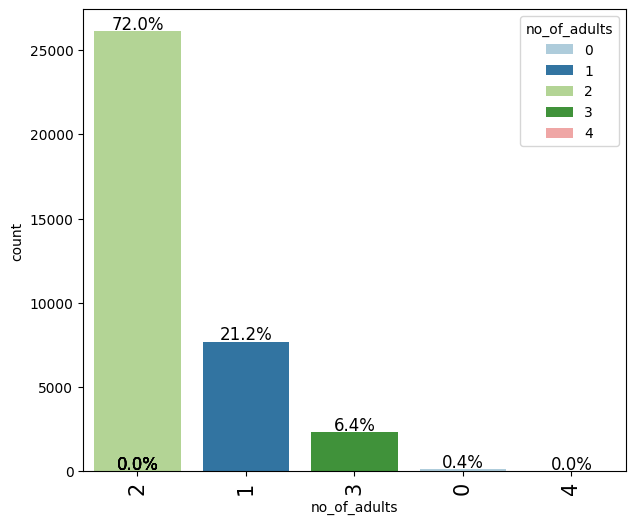


Value counts for no_of_adults:
no_of_adults
2    0.719724
1    0.212130
3    0.063873
0    0.003832
4    0.000441
Name: proportion, dtype: float64

End of Analysis for no_of_adults


Analyzing Categorical Column: no_of_children



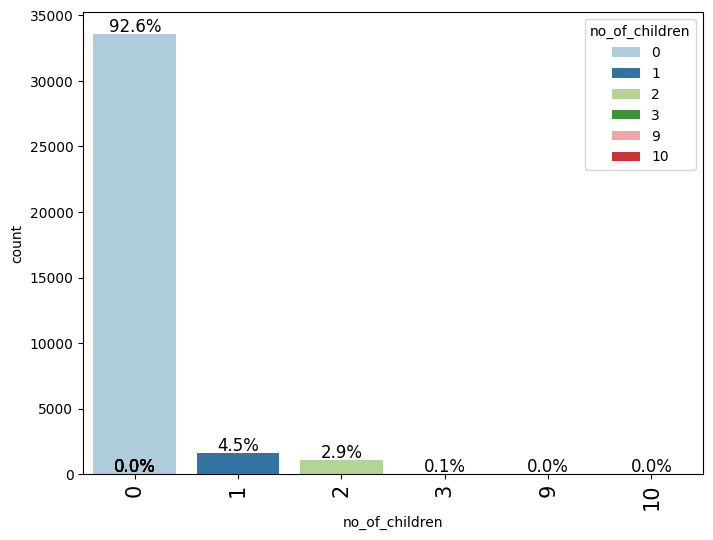


Value counts for no_of_children:
no_of_children
0     0.925624
1     0.044604
2     0.029166
3     0.000524
9     0.000055
10    0.000028
Name: proportion, dtype: float64

End of Analysis for no_of_children


Analyzing Categorical Column: no_of_weekend_nights



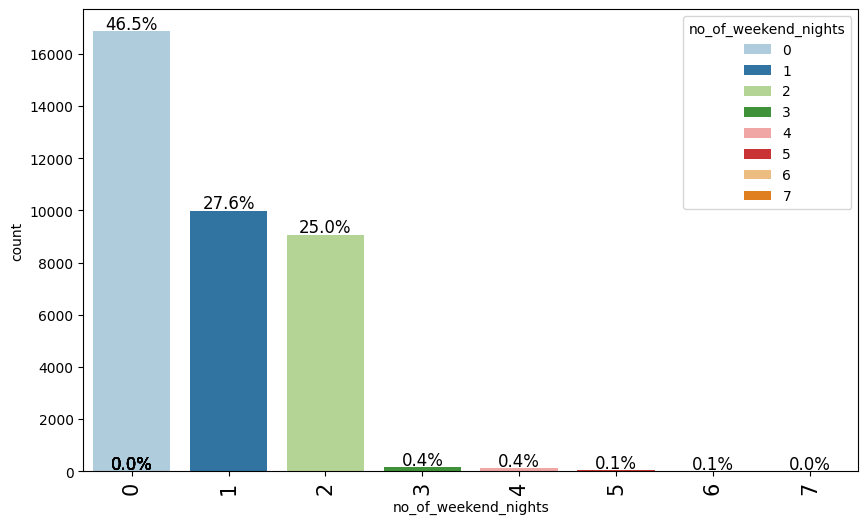


Value counts for no_of_weekend_nights:
no_of_weekend_nights
0    0.465114
1    0.275534
2    0.250062
3    0.004218
4    0.003556
5    0.000937
6    0.000551
7    0.000028
Name: proportion, dtype: float64

End of Analysis for no_of_weekend_nights


Analyzing Categorical Column: no_of_week_nights



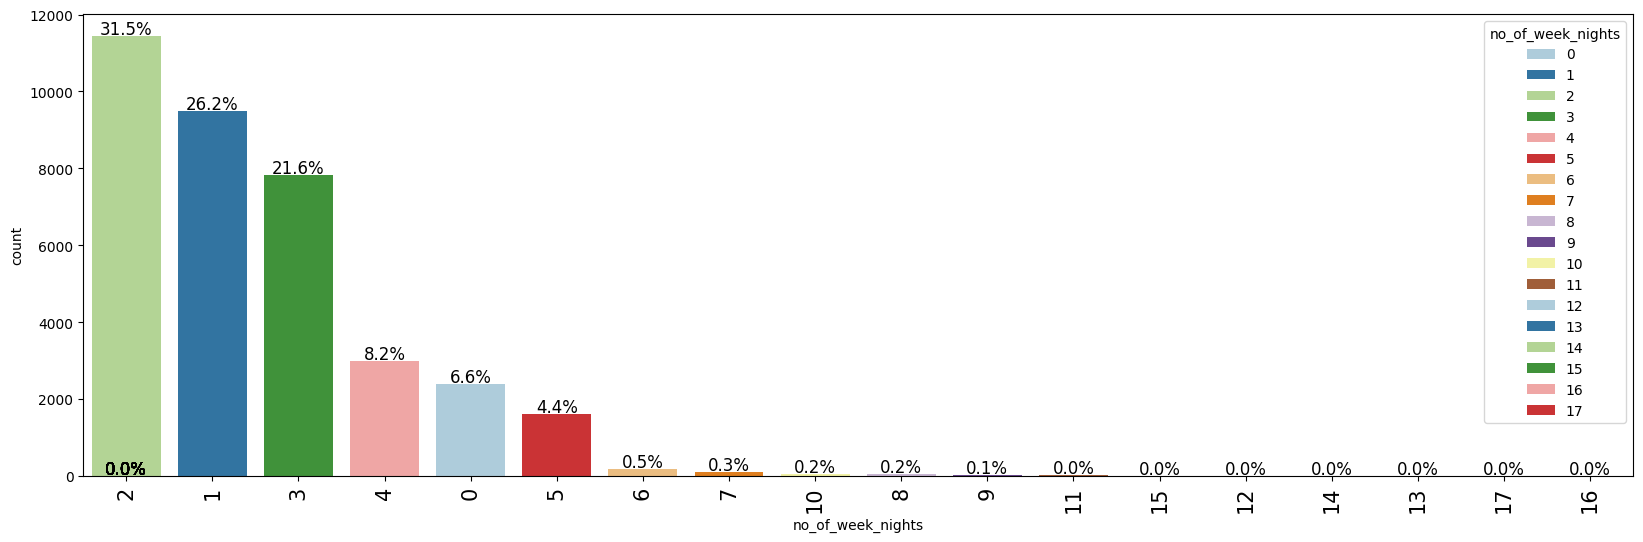


Value counts for no_of_week_nights:
no_of_week_nights
2     0.315479
1     0.261558
3     0.216099
4     0.082426
0     0.065803
5     0.044493
6     0.005210
7     0.003115
10    0.001709
8     0.001709
9     0.000937
11    0.000469
15    0.000276
12    0.000248
14    0.000193
13    0.000138
17    0.000083
16    0.000055
Name: proportion, dtype: float64

End of Analysis for no_of_week_nights


Analyzing Categorical Column: type_of_meal_plan



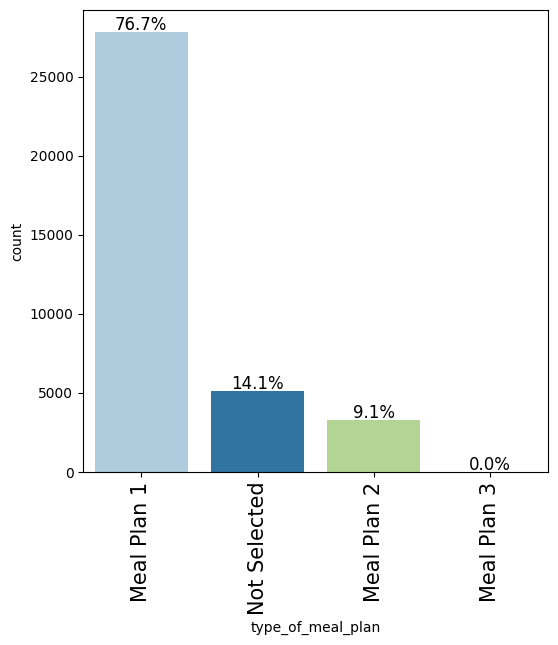


Value counts for type_of_meal_plan:
type_of_meal_plan
Meal Plan 1     0.767333
Not Selected    0.141420
Meal Plan 2     0.091110
Meal Plan 3     0.000138
Name: proportion, dtype: float64

End of Analysis for type_of_meal_plan


Analyzing Categorical Column: required_car_parking_space



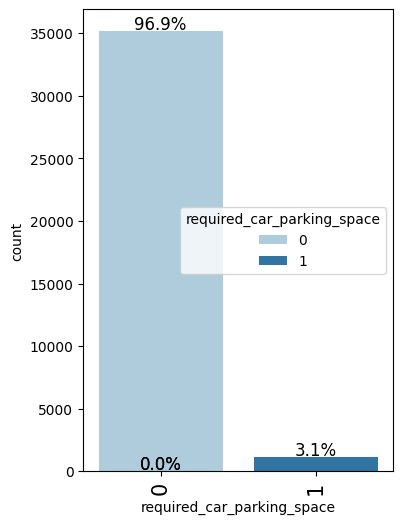


Value counts for required_car_parking_space:
required_car_parking_space
0    0.969014
1    0.030986
Name: proportion, dtype: float64

End of Analysis for required_car_parking_space


Analyzing Categorical Column: room_type_reserved



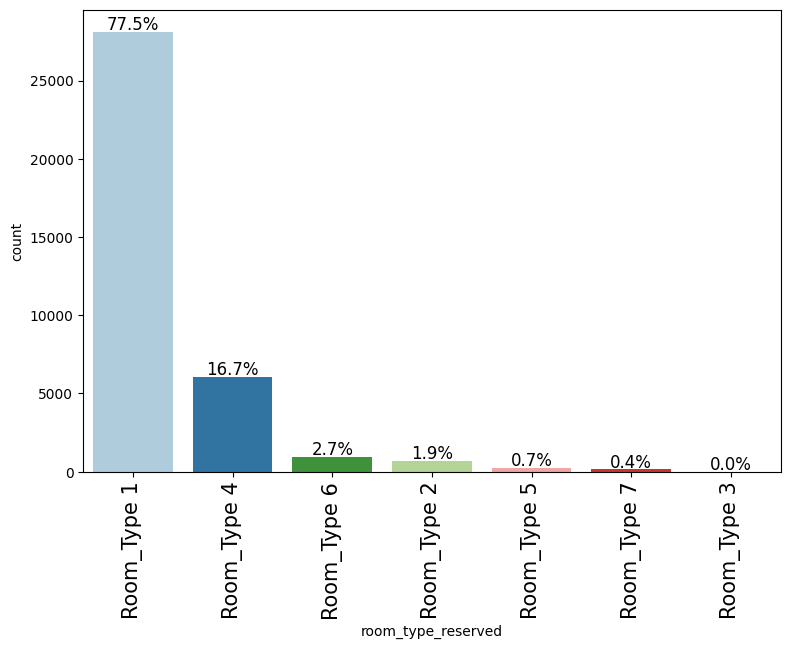


Value counts for room_type_reserved:
room_type_reserved
Room_Type 1    0.775465
Room_Type 4    0.166975
Room_Type 6    0.026630
Room_Type 2    0.019076
Room_Type 5    0.007305
Room_Type 7    0.004356
Room_Type 3    0.000193
Name: proportion, dtype: float64

End of Analysis for room_type_reserved


Analyzing Categorical Column: arrival_year



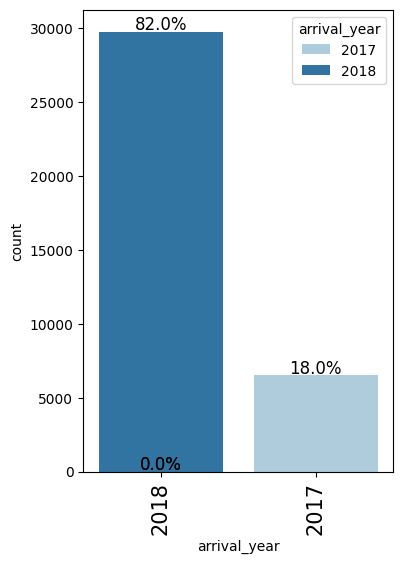


Value counts for arrival_year:
arrival_year
2018    0.820427
2017    0.179573
Name: proportion, dtype: float64

End of Analysis for arrival_year


Analyzing Categorical Column: arrival_month



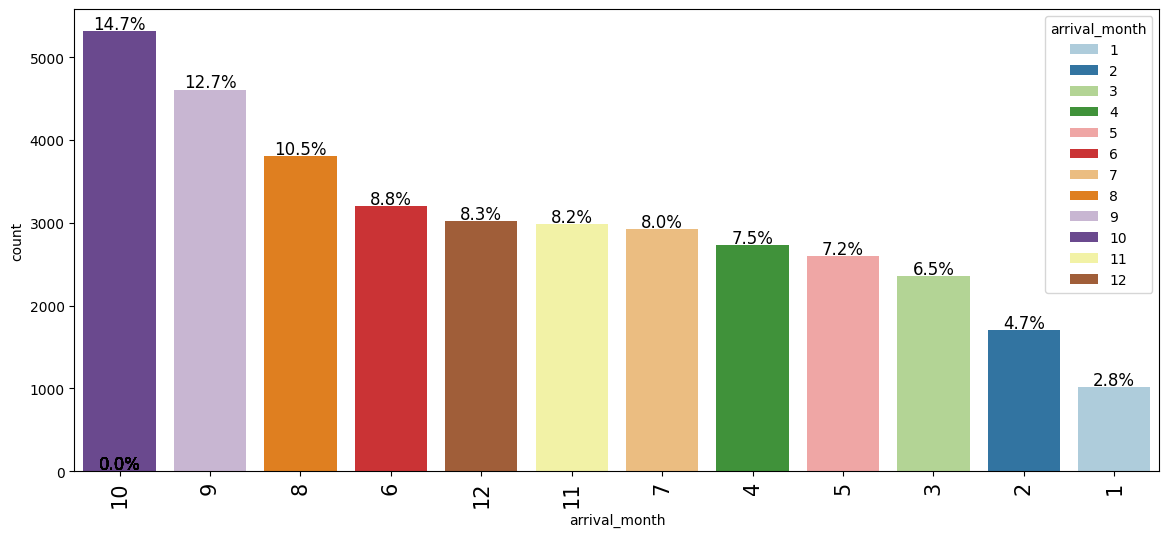


Value counts for arrival_month:
arrival_month
10    0.146575
9     0.127112
8     0.105114
6     0.088298
12    0.083280
11    0.082150
7     0.080496
4     0.075424
5     0.071620
3     0.065003
2     0.046975
1     0.027953
Name: proportion, dtype: float64

End of Analysis for arrival_month


Analyzing Categorical Column: arrival_date



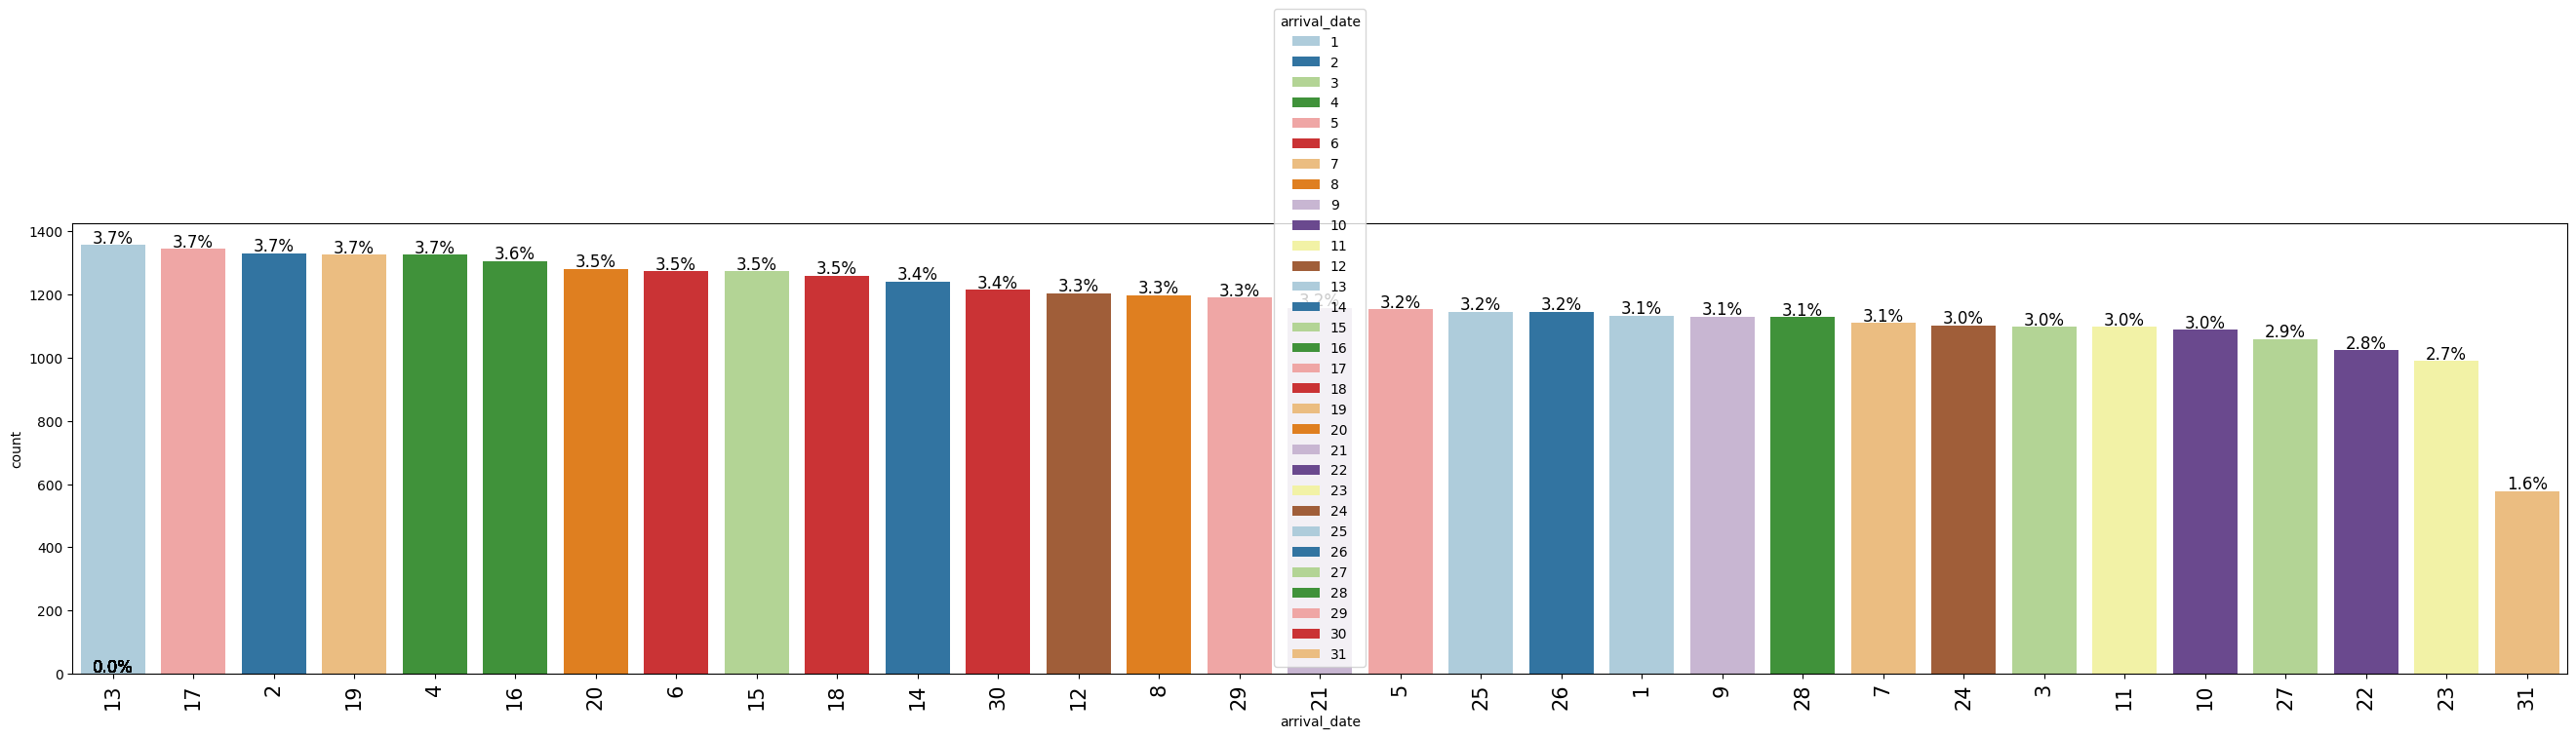


Value counts for arrival_date:
arrival_date
13    0.037436
17    0.037078
2     0.036692
19    0.036582
4     0.036582
16    0.036003
20    0.035314
6     0.035093
15    0.035093
18    0.034735
14    0.034238
30    0.033522
12    0.033191
8     0.033025
29    0.032805
21    0.031923
5     0.031813
25    0.031592
26    0.031592
1     0.031234
9     0.031151
28    0.031123
7     0.030600
24    0.030407
3     0.030269
11    0.030269
10    0.030021
27    0.029194
22    0.028201
23    0.027292
31    0.015934
Name: proportion, dtype: float64

End of Analysis for arrival_date


Analyzing Categorical Column: market_segment_type



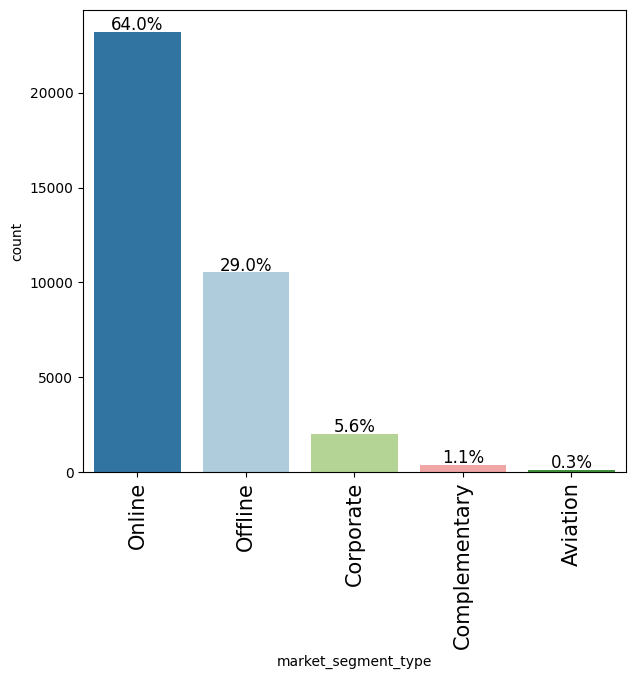


Value counts for market_segment_type:
market_segment_type
Online           0.639945
Offline          0.290227
Corporate        0.055603
Complementary    0.010779
Aviation         0.003446
Name: proportion, dtype: float64

End of Analysis for market_segment_type


Analyzing Categorical Column: repeated_guest



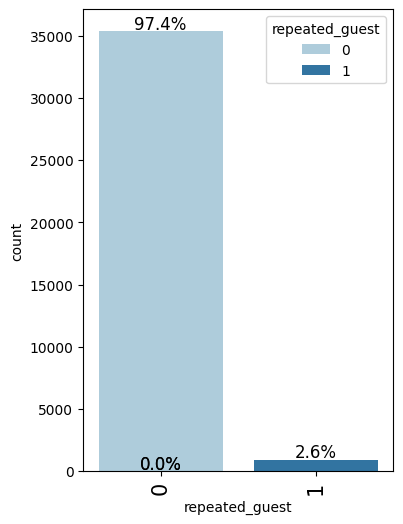


Value counts for repeated_guest:
repeated_guest
0    0.974363
1    0.025637
Name: proportion, dtype: float64

End of Analysis for repeated_guest


Analyzing Categorical Column: no_of_previous_cancellations



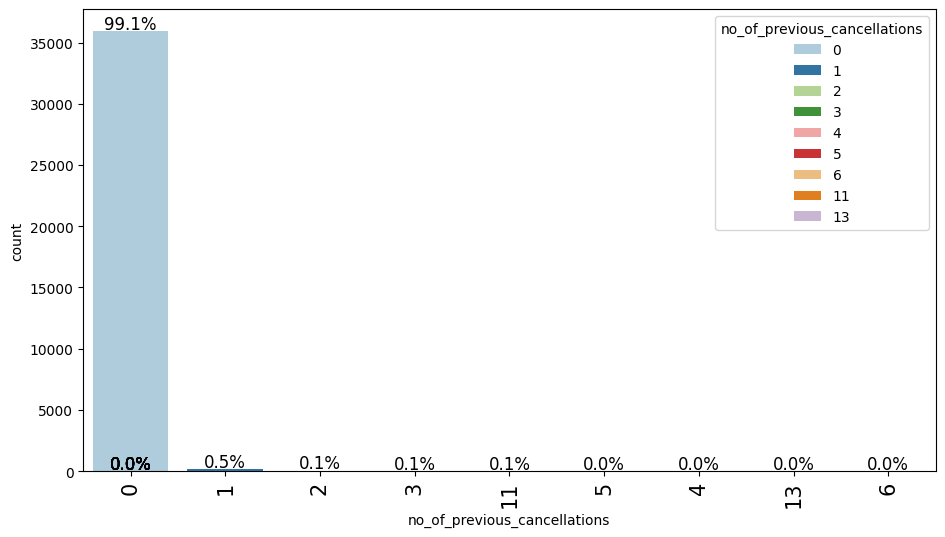


Value counts for no_of_previous_cancellations:
no_of_previous_cancellations
0     0.990682
1     0.005458
2     0.001268
3     0.001185
11    0.000689
5     0.000303
4     0.000276
13    0.000110
6     0.000028
Name: proportion, dtype: float64

End of Analysis for no_of_previous_cancellations


Analyzing Categorical Column: no_of_previous_bookings_not_canceled



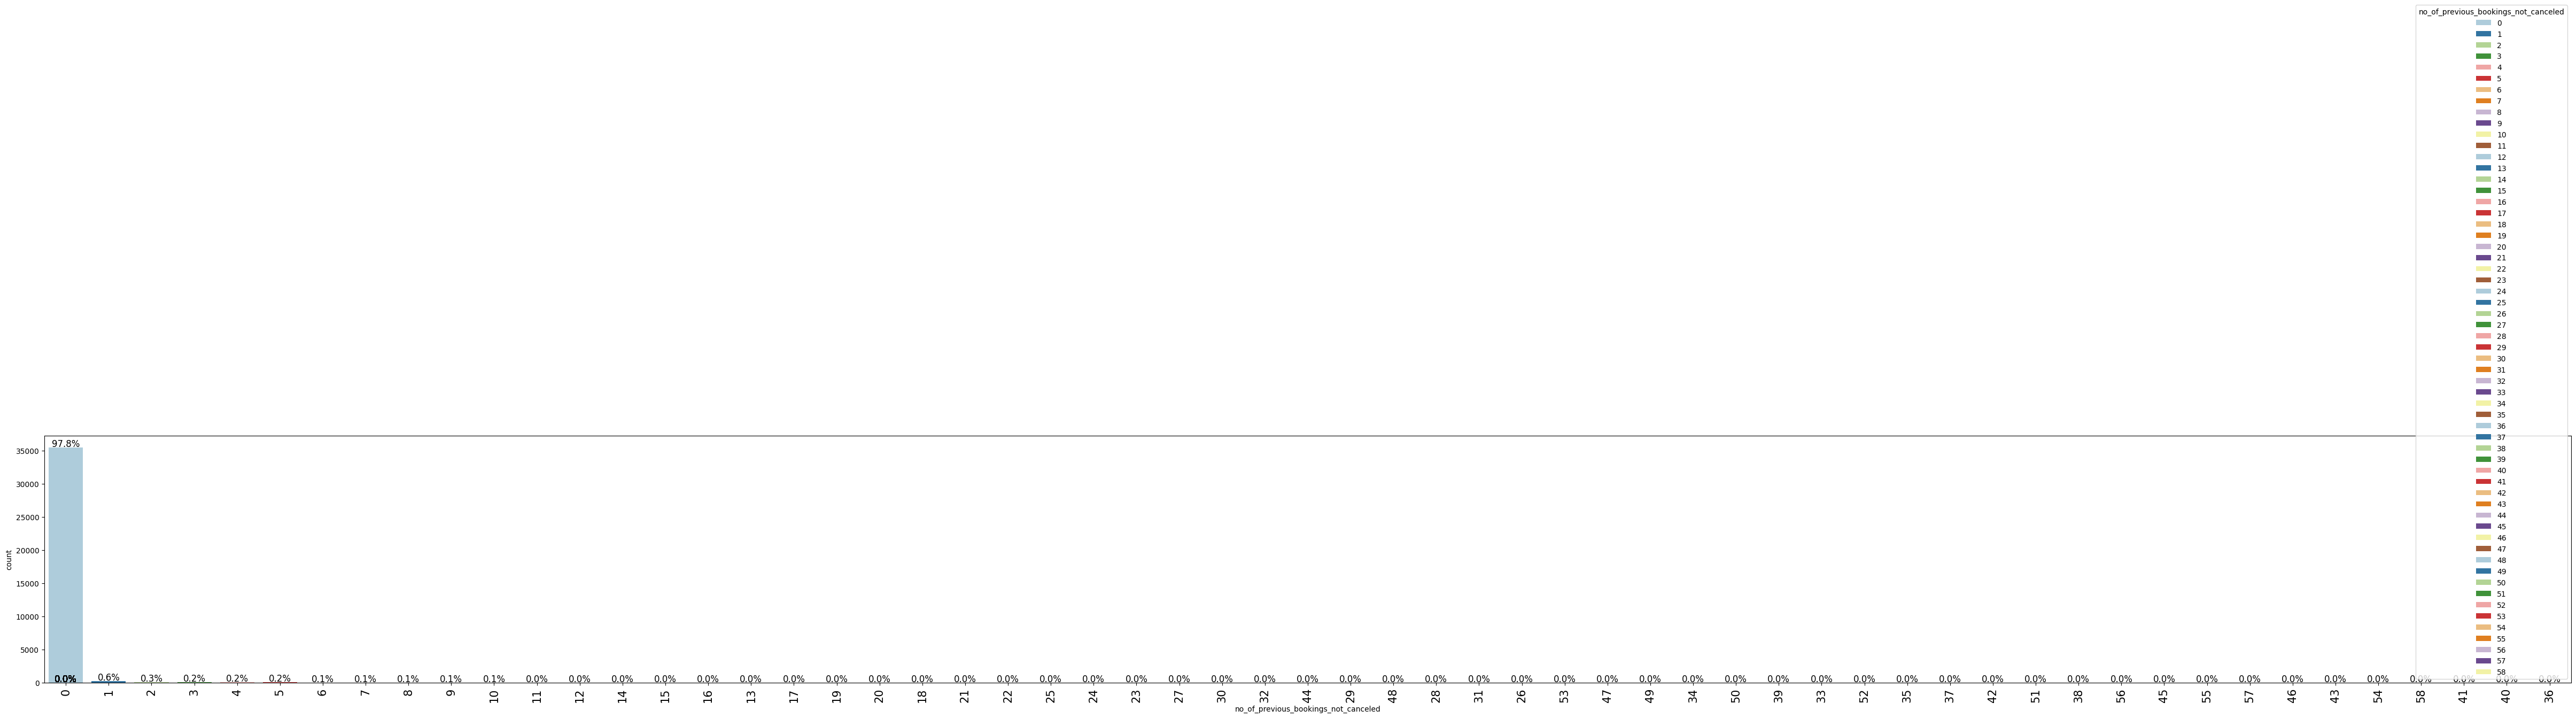


Value counts for no_of_previous_bookings_not_canceled:
no_of_previous_bookings_not_canceled
0     0.977615
1     0.006285
2     0.003088
3     0.002205
4     0.001792
5     0.001654
6     0.000992
7     0.000662
8     0.000634
9     0.000524
10    0.000524
11    0.000414
12    0.000331
14    0.000248
15    0.000221
16    0.000193
13    0.000193
17    0.000165
19    0.000165
20    0.000165
18    0.000165
21    0.000165
22    0.000165
25    0.000083
24    0.000083
23    0.000083
27    0.000083
30    0.000055
32    0.000055
44    0.000055
29    0.000055
48    0.000055
28    0.000055
31    0.000055
26    0.000055
53    0.000028
47    0.000028
49    0.000028
34    0.000028
50    0.000028
39    0.000028
33    0.000028
52    0.000028
35    0.000028
37    0.000028
42    0.000028
51    0.000028
38    0.000028
56    0.000028
45    0.000028
55    0.000028
57    0.000028
46    0.000028
43    0.000028
54    0.000028
58    0.000028
41    0.000028
40    0.000028
36    0.000028
Name: proportion, dtyp

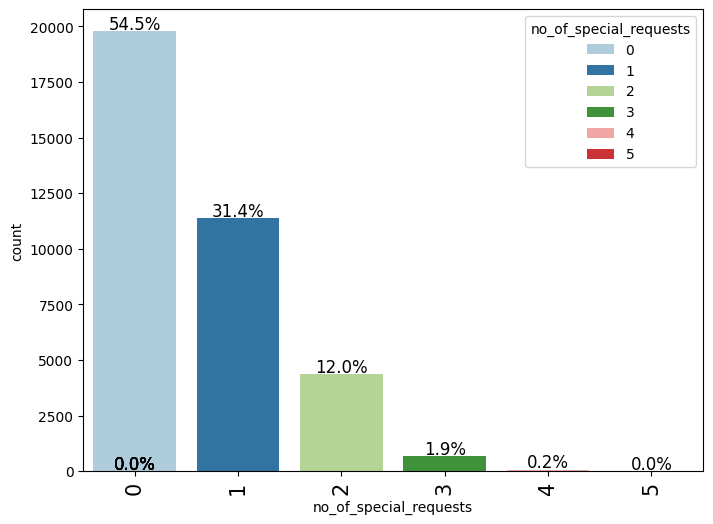


Value counts for no_of_special_requests:
no_of_special_requests
0    0.545196
1    0.313522
2    0.120303
3    0.018608
4    0.002150
5    0.000221
Name: proportion, dtype: float64

End of Analysis for no_of_special_requests


Analyzing Categorical Column: booking_status



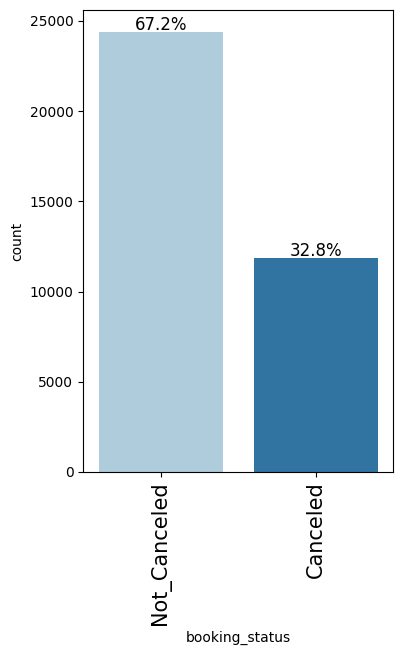


Value counts for booking_status:
booking_status
Not_Canceled    0.672364
Canceled        0.327636
Name: proportion, dtype: float64

End of Analysis for booking_status



In [28]:
for i in cat_cols:
    print(f"\n{'='*70}")
    print(f"Analyzing Categorical Column: {i}")
    print(f"{'='*70}\n")
    labeled_barplot(df, i, perc = True)
    plt.show()
    print(f'\nValue counts for {i}:')
    print(df[i].value_counts(normalize = True))
    print(f"\n{'='*70}")
    print(f"End of Analysis for {i}")
    print(f"{'='*70}\n")

### **Categorical Column Analysis Summary**

### **no_of_adults**
- Over 70% of bookings are for **2 adults**.  
- Around 21% are for **1 adult**.  
- Bookings with 0, 3, or 4 adults are rare.

### **no_of_children**
- More than 92% of bookings include **no children**.  
- Bookings with 1–2 children are uncommon; more than 2 children is very rare.

### **no_of_weekend_nights**
- **46.5%** of bookings include **0 weekend nights**, indicating weekday stays.  
- Stays with **1 or 2 weekend nights** each make up roughly a quarter of bookings.

### **no_of_week_nights**
- Stays of **1–3 weeknights** account for over **79%** of bookings.  
- Longer stays occur less frequently.

### **type_of_meal_plan**
- **Meal Plan 1** is the most selected option (over 76%).  
- **Not Selected** accounts for ~14%.  
- **Meal Plan 2** makes up ~9%.  
- **Meal Plan 3** is extremely rare.

### **required_car_parking_space**
- Over **96%** of bookings do **not** require parking, showing low demand.

### **room_type_reserved**
- **Room_Type 1** dominates with over 77% of bookings.  
- **Room_Type 4** follows at ~16%.  
- Other room types are rarely chosen.

### **arrival_year**
- More than **82%** of bookings are for **2018**.  
- The remaining 18% are for **2017**.

### **arrival_month**
- **October, September, and August** are the busiest months (38%+ combined).  
- **January** has the lowest number of arrivals.

### **arrival_date**
- Arrival dates are evenly distributed across the month with no major peaks.

### **market_segment_type**
- **Online** bookings dominate (~64%).  
- **Offline** accounts for ~29%.  
- **Corporate**, **Complementary**, and **Aviation** segments are minimal.

### **repeated_guest**
- Over **97%** of guests are **not** repeat visitors.

### **no_of_previous_cancellations**
- More than **99%** of guests have **0 previous cancellations**.

### **no_of_previous_bookings_not_canceled**
- Over **97%** have **0 previous successful bookings**, consistent with low repeat‑guest rates.

### **no_of_special_requests**
- **54.5%** of bookings include **no special requests**.  
- **31.3%** include **1 request**.  
- Two or more requests are less common.




In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   type_of_meal_plan                     36275 non-null  object 
 5   required_car_parking_space            36275 non-null  int64  
 6   room_type_reserved                    36275 non-null  object 
 7   lead_time                             36275 non-null  int64  
 8   arrival_year                          36275 non-null  int64  
 9   arrival_month                         36275 non-null  int64  
 10  arrival_date                          36275 non-null  int64  
 11  market_segment_


--- Analyzing Column: avg_price_per_room ---

Data Type:
float64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,avg_price_per_room
count,36275.000000
mean,103.423539
std,35.089424
min,0.000000
25%,80.300000
50%,99.450000
75%,120.000000
max,540.000000


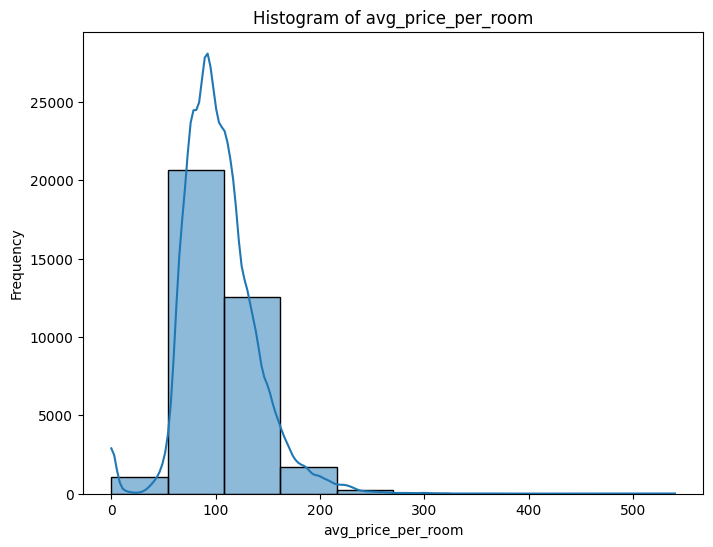

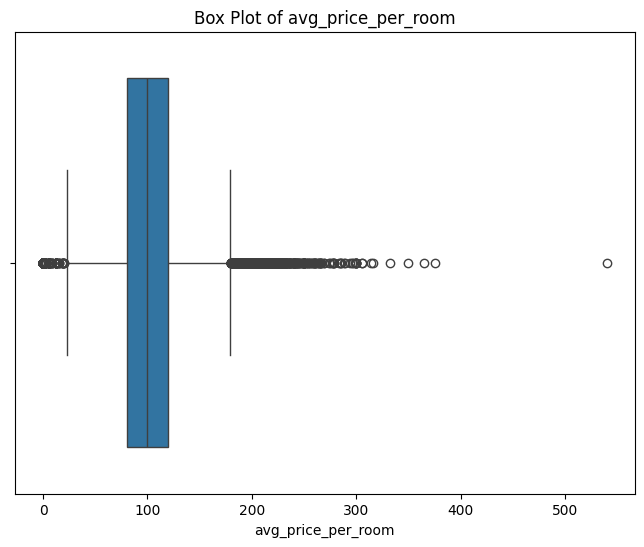


--- Analysis Complete for Column: avg_price_per_room ---


In [30]:
analyzer.analyze_column('avg_price_per_room')


--- Analyzing Column: lead_time ---

Data Type:
int64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,lead_time
count,36275.000000
mean,85.232557
std,85.930817
min,0.000000
25%,17.000000
50%,57.000000
75%,126.000000
max,443.000000


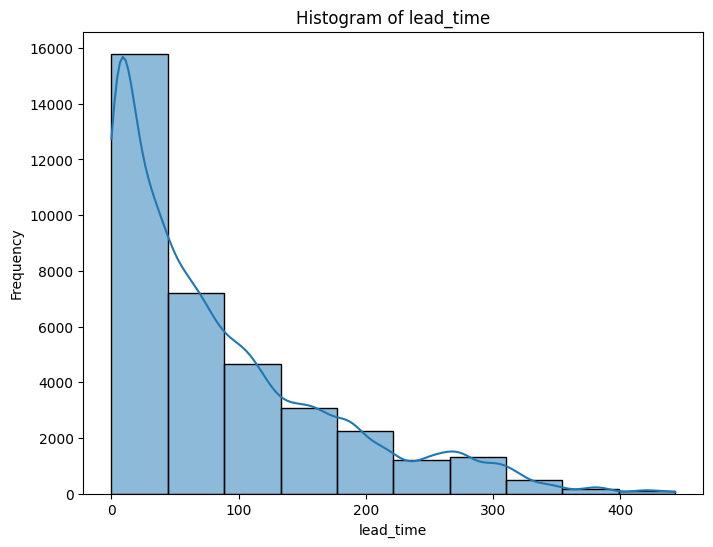

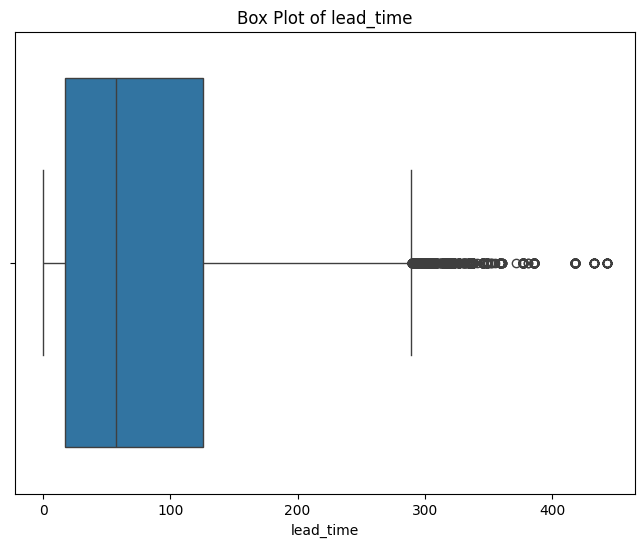


--- Analysis Complete for Column: lead_time ---


In [31]:
analyzer.analyze_column('lead_time')

### Univariate Analysis Summary: Numerical Columns

### `avg_price_per_room`

- **Key Statistics:**
  - **Count:** 36,275
  - **Mean:** 103.42 EUR
  - **Median (50th percentile):** 99.45 EUR
  - **Standard Deviation:** 35.09 EUR
  - **Minimum:** 0.00 EUR
  - **Maximum:** 540.00 EUR
  - **25th Percentile:** 80.30 EUR
  - **75th Percentile:** 120.00 EUR
- **Observations:**
  - The average price per room is around 103.42 EUR, with a moderate spread.
  - The mean being slightly higher than the median suggests a slight right-skewness, indicating some higher-priced rooms.
  - A minimum price of 0.00 EUR is notable and could indicate promotional bookings, complimentary stays, or potential data entry issues that might require further investigation.
  - The maximum price of 540 EUR indicates a wide range, with potential outliers at the higher end.

### `lead_time`

- **Key Statistics:**
  - **Count:** 36,275
  - **Mean:** 85.23 days
  - **Median (50th percentile):** 57.00 days
  - **Standard Deviation:** 85.93 days
  - **Minimum:** 0 days
  - **Maximum:** 443 days
  - **25th Percentile:** 17.00 days
  - **75th Percentile:** 126.00 days
- **Observations:**
  - The `lead_time` varies significantly, ranging from 0 days (same-day booking) to 443 days (booked over a year in advance).
  - The mean (85.23 days) is considerably higher than the median (57 days), indicating a strong right-skewness. This means many bookings have shorter lead times, but there are also a substantial number of bookings made far in advance.
  - The high standard deviation (85.93 days) further emphasizes the wide variability in booking lead times.
  - This distribution suggests a mixed customer base, including spontaneous travelers and those planning trips well in advance.

In [32]:
df100 = df.copy()

In [33]:
df["booking_status"] = (df["booking_status"] != "Not_Canceled").astype(int)


In [34]:
df.booking_status.value_counts()

,count
booking_status,
0,24390
1,11885


## Bivariate analysis

In [35]:
bivariate_analyzer = BivariateAnalyzer(df)

In [36]:
# SPlit the columns to 2 List , categorical and Numerical
cat , nums = [], []
for i in df.columns:
    if df[i].dtypes != 'object':
        nums.append(i)
    else:
        cat.append(i)
print(cat)
print(nums)

['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']


In [37]:
#sns.pairplot(df[nums])

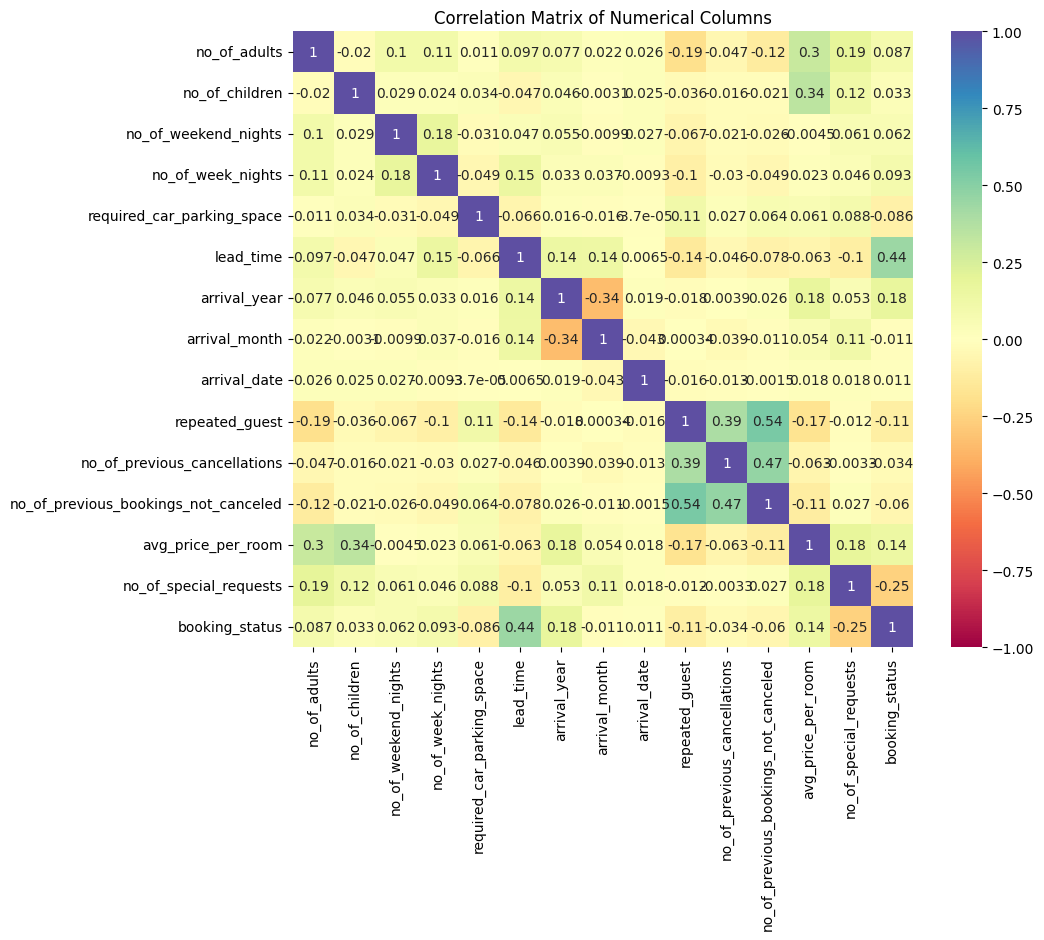

In [38]:
bivariate_analyzer.plot_correlation_matrix()

**Exploring Relationships between Categorical and Numerical Variables**

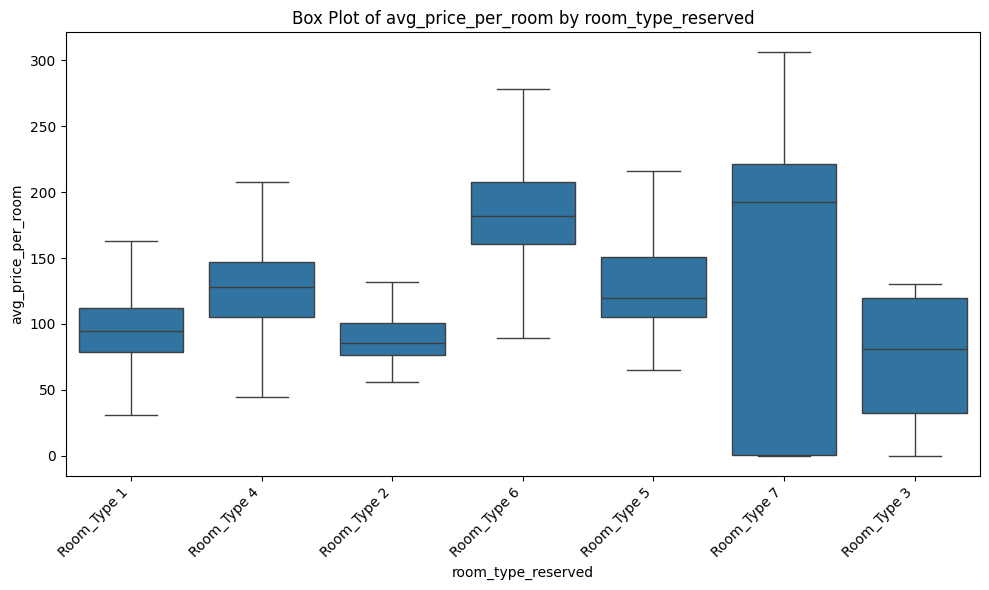

In [39]:
bivariate_analyzer.plot_numerical_categorical('avg_price_per_room', 'room_type_reserved', kind='boxplot')

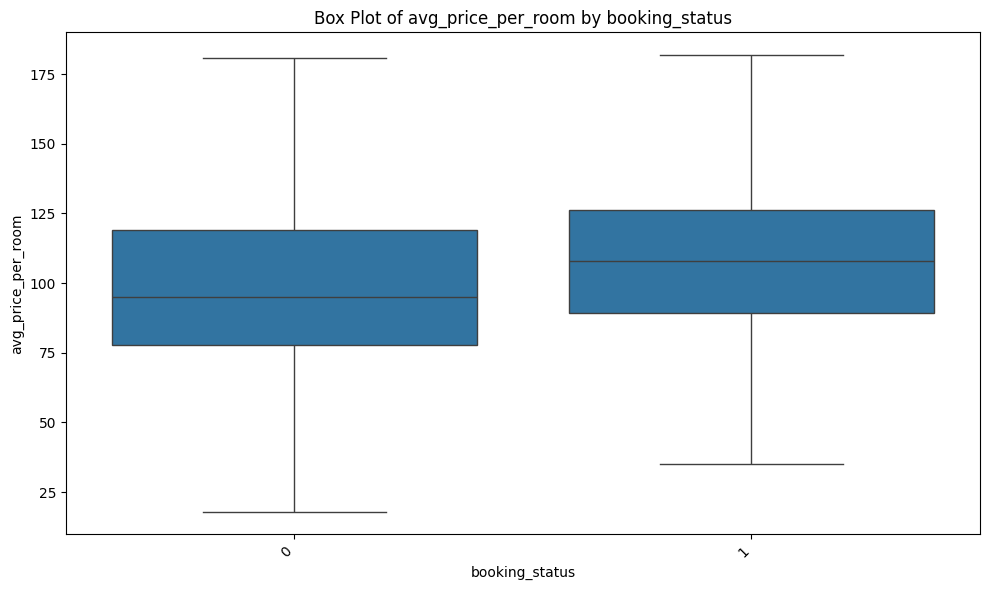

In [40]:
bivariate_analyzer.plot_numerical_categorical('avg_price_per_room', 'booking_status', kind='boxplot')

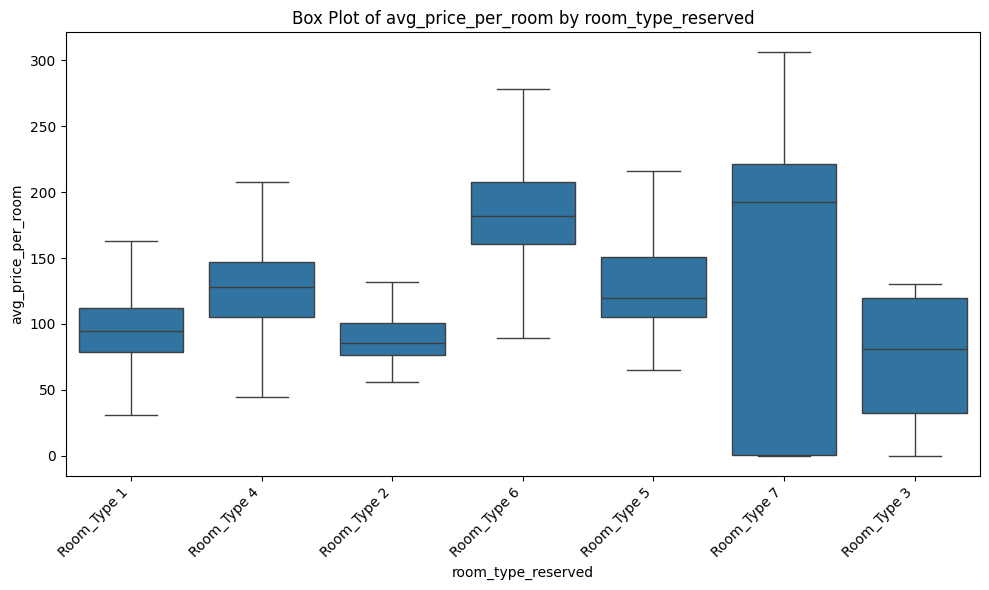

In [41]:
bivariate_analyzer.plot_numerical_categorical('avg_price_per_room', 'room_type_reserved', kind='boxplot')

In [42]:
# Re-instantiate BivariateAnalyzer with the updated DataFrame
bivariate_analyzer = BivariateAnalyzer(df)

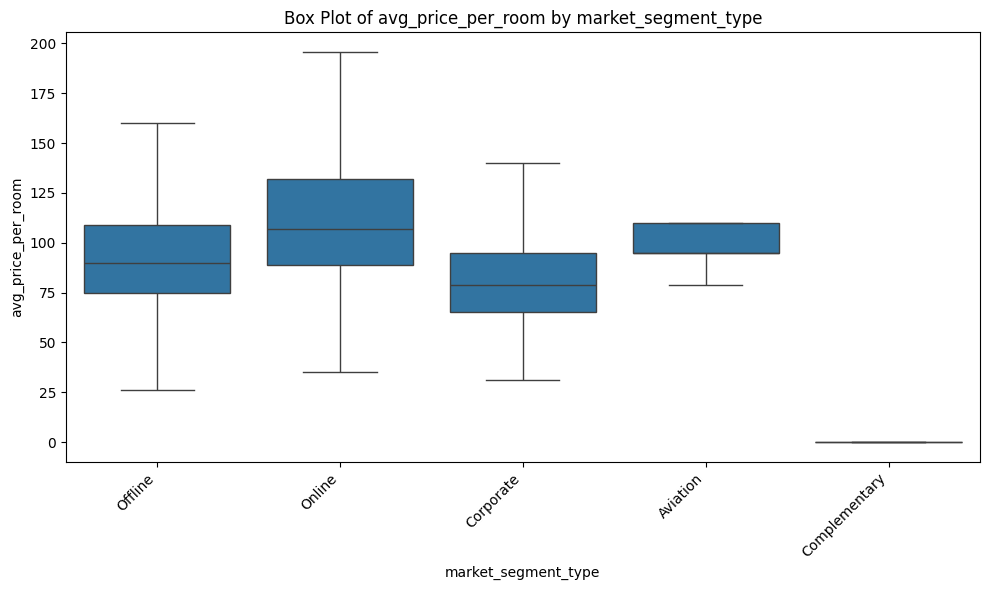

In [43]:
bivariate_analyzer.plot_numerical_categorical('avg_price_per_room', 'market_segment_type', kind='boxplot')


Analyzing Cancellation Rate for Repeating Guests

booking_status      0      1    All
repeated_guest                     
All             24390  11885  36275
0               23476  11869  35345
1                 914     16    930
------------------------------------------------------------------------------------------------------------------------


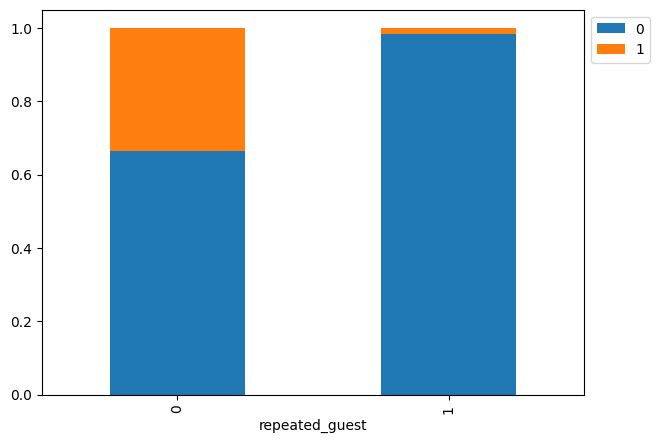

In [44]:
print(f"\n{'='*70}")
print("Analyzing Cancellation Rate for Repeating Guests")
print(f"{'='*70}\n")
stacked_barplot(df, 'repeated_guest', 'booking_status')



Analyzing the effect of Special Requests on Booking Cancellation

booking_status              0      1    All
no_of_special_requests                     
All                     24390  11885  36275
0                       11232   8545  19777
1                        8670   2703  11373
2                        3727    637   4364
3                         675      0    675
4                          78      0     78
5                           8      0      8
------------------------------------------------------------------------------------------------------------------------


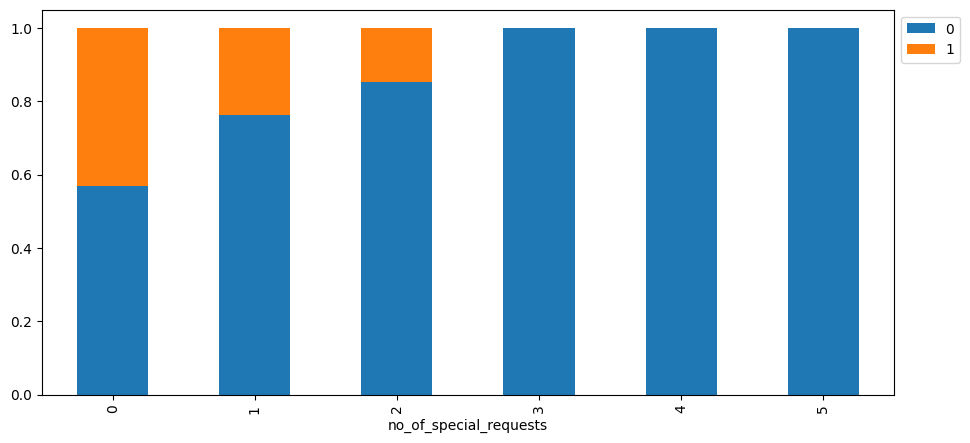

In [45]:
print(f"\n{'='*70}")
print("Analyzing the effect of Special Requests on Booking Cancellation")
print(f"{'='*70}\n")
stacked_barplot(df, 'no_of_special_requests', 'booking_status')

### **Bivariate Analysis Summary: Insights**

**EDA Questions**

### **3. Room Prices Across Market Segments (`avg_price_per_room` vs. `market_segment_type`)**
- **Observations:**
  - The box plot for `avg_price_per_room` across `market_segment_type` shows significant variation.
  - **Online** and **Offline** segments have a wide distribution of prices, with Online generally showing higher median prices and more outliers on the higher end.
  - **Corporate** bookings typically have lower average prices and a tighter distribution, suggesting negotiated rates or simpler room types.
  - **Complementary** and **Aviation** segments show very low prices, often close to zero, which is expected for complementary stays or special airline agreements.
- **Conclusion:** Market segment is a strong indicator of average room price, with Online bookings commanding higher and more varied prices compared to Corporate or Complementary segments.

### **5. Cancellation Rate for Repeating Guests (`repeated_guest` vs. `booking_status`)**
- **Observations:**
  - From the stacked bar plot and cross-tabulation:
    - **Non-repeated guests (0):** Out of 35,345 non-repeated guests, 11,869 (approx. 33.6%) canceled their bookings, and 23,476 (approx. 66.4%) did not cancel.
    - **Repeated guests (1):** Out of 930 repeated guests, only 16 (approx. 1.7%) canceled their bookings, while 914 (approx. 98.3%) did not cancel.
- **Conclusion:** Repeated guests have a significantly lower cancellation rate (1.7%) compared to non-repeated guests (33.6%). This indicates that loyal customers are much less likely to cancel their bookings, highlighting the value of guest retention.

### **6. Effect of Special Requests on Booking Cancellation (`no_of_special_requests` vs. `booking_status`)**
- **Observations:**
  - From the stacked bar plot and cross-tabulation:
    - **0 special requests:** 8,545 out of 19,777 bookings (approx. 43.2%) with no special requests were canceled.
    - **1 special request:** 2,703 out of 11,373 bookings (approx. 23.8%) with one special request were canceled.
    - **2 special requests:** 637 out of 4,364 bookings (approx. 14.6%) with two special requests were canceled.
    - **3 or more special requests:** Bookings with 3, 4, or 5 special requests showed **zero cancellations**.
- **Conclusion:** There is a clear inverse relationship: as the number of special requests increases, the likelihood of a booking being canceled significantly decreases. Guests with more special requests are highly committed to their bookings, suggesting that accommodating these requests could be a strategy to reduce cancellations.

# EDA Questions

### EDA Questions

Based on the univariate and bivariate analyses performed, here are the answers to your questions:

### 1. What are the busiest months in the hotel?
*   **Answer:** The busiest months for hotel arrivals are **October, September, and August**. These three months collectively account for over 38% of all bookings, with October being the single busiest month (around 14.7% of all arrivals). Conversely, January shows the lowest number of arrivals.

### 2. Which market segment do most of the guests come from?
*   **Answer:** Most guests come from the **Online market segment**, which dominates with approximately **64%** of all bookings. The Offline segment is the second largest, accounting for about 29% of bookings. Corporate, Complementary, and Aviation segments represent a much smaller portion of the total guests.

### 3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
*   **Answer:** There are significant differences in room prices across market segments:
    *   **Online** and **Offline** segments exhibit a wide distribution of room prices, with Online bookings generally having higher median prices and more outliers on the higher end.
    *   **Corporate** bookings typically show lower average prices and a tighter distribution, suggesting negotiated rates or simpler room types.
    *   **Complementary** and **Aviation** segments often have very low prices, in some cases close to zero, which is expected for complimentary stays or special agreements.
    *   **Conclusion:** The market segment is a strong indicator of average room price, with Online bookings commanding higher and more varied prices compared to Corporate or Complementary segments.

### 4. What percentage of bookings are canceled?
*   **Answer:** Approximately **32.8%** of all bookings are canceled. The `booking_status` distribution shows 11,885 canceled bookings out of a total of 36,275.

### 5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
*   **Answer:** Repeating guests have a significantly lower cancellation rate. Out of 930 repeated guests, only 16 canceled their bookings, resulting in a cancellation rate of approximately **1.7%**. This is in stark contrast to non-repeated guests, who have a cancellation rate of about 33.6%.

### 6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?
*   **Answer:** Yes, special requirements significantly affect booking cancellation, showing a clear inverse relationship:
    *   Bookings with **0 special requests** have a cancellation rate of approximately **43.2%**.
    *   Bookings with **1 special request** have a cancellation rate of approximately **23.8%**.
    *   Bookings with **2 special requests** have a cancellation rate of approximately **14.6%**.
    *   Bookings with **3 or more special requests** show **zero cancellations**.
    *   **Conclusion:** Guests with more special requests are highly committed to their bookings, suggesting that accommodating these requests could be a strategy to reduce cancellations.

**Reasoning**:
To identify bookings with zero average price per room, I will filter the 'df' DataFrame where 'avg_price_per_room' is 0, store it in a new DataFrame named 'zeroprice_bookings', and then display the first five rows.



In [46]:
zeroprice_bookings = df[df['avg_price_per_room'] == 0.0]
print("First 5 rows of bookings with zero average price per room:")
display(zeroprice_bookings.head())

First 5 rows of bookings with zero average price per room:


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
63,1,0,0,1,Meal Plan 1,0,Room_Type 1,2,2017,9,10,Complementary,0,0,0,0.0,1,0
145,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.0,1,0
209,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.0,1,0
266,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.0,1,0
267,1,0,2,1,Meal Plan 1,0,Room_Type 1,4,2017,8,23,Complementary,0,0,0,0.0,1,0


In [47]:
print("\n--- Info for Zero-Price Bookings ---\n")
zeroprice_bookings.info()
print("\n--- Summary Statistics for Zero-Price Bookings ---\n")
display(zeroprice_bookings.describe().T)


--- Info for Zero-Price Bookings ---

<class 'pandas.core.frame.DataFrame'>
Index: 545 entries, 63 to 36250
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          545 non-null    int64  
 1   no_of_children                        545 non-null    int64  
 2   no_of_weekend_nights                  545 non-null    int64  
 3   no_of_week_nights                     545 non-null    int64  
 4   type_of_meal_plan                     545 non-null    object 
 5   required_car_parking_space            545 non-null    int64  
 6   room_type_reserved                    545 non-null    object 
 7   lead_time                             545 non-null    int64  
 8   arrival_year                          545 non-null    int64  
 9   arrival_month                         545 non-null    int64  
 10  arrival_date                          545 non-nul

,count,mean,std,min,25%,50%,75%,max
no_of_adults,545.0,1.451376,0.540563,0.0,1.0,1.0,2.0,4.0
no_of_children,545.0,0.093578,0.388785,0.0,0.0,0.0,0.0,3.0
no_of_weekend_nights,545.0,0.284404,0.576688,0.0,0.0,0.0,0.0,4.0
no_of_week_nights,545.0,1.148624,0.989802,0.0,1.0,1.0,2.0,10.0
required_car_parking_space,545.0,0.049541,0.217195,0.0,0.0,0.0,0.0,1.0
lead_time,545.0,22.772477,54.461464,0.0,0.0,4.0,12.0,346.0
arrival_year,545.0,2017.572477,0.495174,2017.0,2017.0,2018.0,2018.0,2018.0
arrival_month,545.0,8.016514,3.333446,1.0,6.0,9.0,11.0,12.0
arrival_date,545.0,14.763303,8.278967,1.0,9.0,14.0,21.0,31.0
repeated_guest,545.0,0.233028,0.423148,0.0,0.0,0.0,0.0,1.0


In [48]:
print("\n--- Value Counts for Key Categorical Columns in Zero-Price Bookings ---\n")

print("Market Segment Type:")
display(zeroprice_bookings['market_segment_type'].value_counts(normalize=True))

print("\nRepeated Guest:")
display(zeroprice_bookings['repeated_guest'].value_counts(normalize=True))

print("\nBooking Status (Canceled=1, Not Canceled=0):")
display(zeroprice_bookings['booking_status'].value_counts(normalize=True))

print("\nNumber of Adults:")
display(zeroprice_bookings['no_of_adults'].value_counts(normalize=True))

print("\nNumber of Children:")
display(zeroprice_bookings['no_of_children'].value_counts(normalize=True))

print("\nNumber of Previous Cancellations:")
display(zeroprice_bookings['no_of_previous_cancellations'].value_counts(normalize=True))


--- Value Counts for Key Categorical Columns in Zero-Price Bookings ---

Market Segment Type:


,proportion
market_segment_type,
Complementary,0.649541
Online,0.350459



Repeated Guest:


,proportion
repeated_guest,
0,0.766972
1,0.233028



Booking Status (Canceled=1, Not Canceled=0):


...

,proportion
no_of_adults,
1,0.546789
2,0.434862
3,0.009174
0,0.007339
4,0.001835



Number of Children:


,proportion
no_of_children,
0,0.935780
1,0.038532
2,0.022018
3,0.003670



Number of Previous Cancellations:


,proportion
no_of_previous_cancellations,
0,0.933945
2,0.025688
1,0.016514
3,0.012844
4,0.011009


## Analysis of Zero-Price Bookings

### Analysis of Zero-Price Bookings

**Total Zero-Price Bookings:** 545 entries.

### **Key Characteristics of Zero-Price Bookings:**

1.  **`market_segment_type`:**
    *   **Complementary:** Dominates with approximately **65%** of zero-price bookings.
    *   **Online:** Accounts for the remaining **35%**.
    *   *Insight:* The high proportion of 'Complementary' bookings strongly suggests these are not standard revenue-generating stays.

2.  **`repeated_guest`:**
    *   **Not Repeated:** Approximately **76.7%** are not repeated guests.
    *   **Repeated:** Approximately **23.3%** are repeated guests.
    *   *Insight:* While a majority are non-repeated, the percentage of repeated guests (23.3%) is significantly higher than in the overall dataset (2.56%). This could indicate staff bookings or loyal customer rewards.

3.  **`booking_status`:**
    *   **Not Canceled:** An overwhelming **98.9%** of zero-price bookings are *not canceled*.
    *   **Canceled:** Only about **1.1%** are canceled.
    *   *Insight:* This extremely low cancellation rate further supports the idea that these bookings are highly committed, likely due to their nature (e.g., complimentary, staff, special agreements).

4.  **`no_of_adults` & `no_of_children`:**
    *   Most zero-price bookings are for **1 adult (~54.7%)** or **2 adults (~43.5%)**, with very few children (93.6% have 0 children).
    *   *Insight:* This demographic profile might align with individual staff members, couples on special offers, or specific corporate/complementary arrangements.

5.  **`no_of_previous_cancellations`:**
    *   **0 previous cancellations:** About **93.4%**.
    *   *Insight:* This is slightly lower than the overall dataset (99%), suggesting a minor but notable presence of guests with a history of previous cancellations among zero-price bookings. This could be due to specific arrangements to retain customers.

### **Potential Reasons for Zero-Price Bookings:**

Based on these observations, potential reasons for bookings with an `avg_price_per_room` of 0.0 include:

*   **Complimentary Stays:** Explicitly indicated by the high proportion from the 'Complementary' market segment. These could be for VIP guests, contest winners, service recovery, or marketing purposes.
*   **Staff Bookings:** Employees receiving free or highly discounted stays, which would likely be marked as zero price in the system.
*   **Promotional Offers/Vouchers:** Bookings fully covered by special promotions or gift vouchers where the guest pays nothing directly.
*   **Data Entry Errors:** While less likely given the consistent patterns, it's always a possibility that some entries are mistakes.
*   **Blocked Rooms for Internal Use:** Rooms held for events, maintenance, or internal purposes that don't generate revenue.



# Time Series Trend Analysis

**Time Series Analysis**:
Create a new column named `arrival_date_full` by combining the `arrival_year`, `arrival_month`, and `arrival_date` columns into a datetime format. This step is crucial for time series analysis.



In [49]:
df['arrival_date_full'] = pd.to_datetime(df['arrival_year'].astype(str) + '-' + df['arrival_month'].astype(str) + '-' + df['arrival_date'].astype(str), errors='coerce')
print("Created 'arrival_date_full' column and converted it to datetime format, coercing invalid dates to NaT.")

Created 'arrival_date_full' column and converted it to datetime format, coercing invalid dates to NaT.


In [50]:
canceled_bookings_ts = df[df['booking_status'] == 1].groupby('arrival_date_full').size().reset_index(name='number_of_bookings')
print("Created 'canceled_bookings_ts' DataFrame.")

not_canceled_bookings_ts = df[df['booking_status'] == 0].groupby('arrival_date_full').size().reset_index(name='number_of_bookings')
print("Created 'not_canceled_bookings_ts' DataFrame.")

Created 'canceled_bookings_ts' DataFrame.
Created 'not_canceled_bookings_ts' DataFrame.


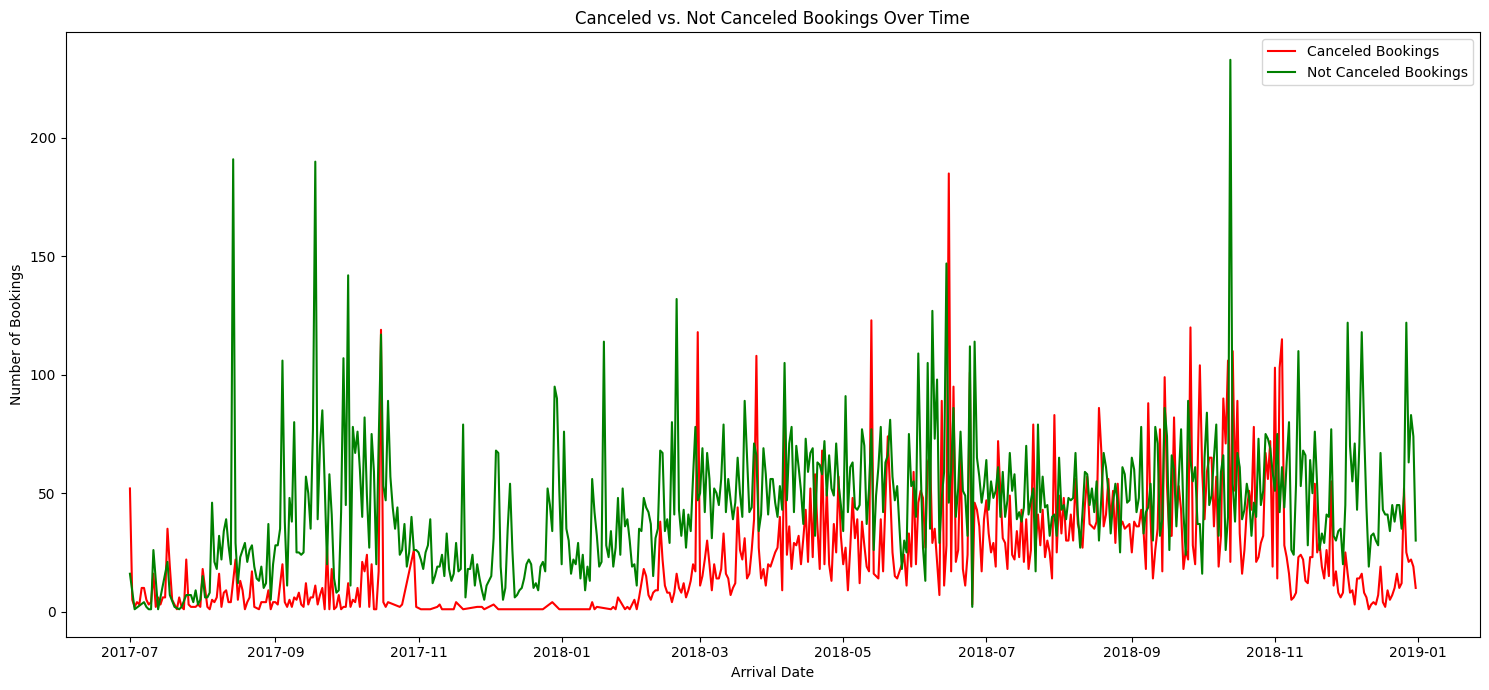

Generated line plot showing canceled and not canceled bookings over time.


In [51]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=canceled_bookings_ts, x='arrival_date_full', y='number_of_bookings', label='Canceled Bookings', color='red')
sns.lineplot(data=not_canceled_bookings_ts, x='arrival_date_full', y='number_of_bookings', label='Not Canceled Bookings', color='green')
plt.title('Canceled vs. Not Canceled Bookings Over Time')
plt.xlabel('Arrival Date')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()
print("Generated line plot showing canceled and not canceled bookings over time.")

## Summary:



### Data Analysis Key Findings
*   The `arrival_date_full` column was successfully constructed by combining `arrival_year`, `arrival_month`, and `arrival_date` from the dataset.
*   The dataset contained invalid date combinations (e.g., "February 30th"), which initially caused a `ValueError` during datetime conversion.
*   This issue was addressed by using `errors='coerce'` during the `pd.to_datetime` operation, which effectively converted invalid dates to `NaT` (Not a Time) values, allowing the process to complete without error.
*   Two aggregated DataFrames were successfully created: `canceled_bookings_ts` for bookings with `booking_status == 1` and `not_canceled_bookings_ts` for bookings with `booking_status == 0`. Both contain the daily count of bookings (`number_of_bookings`) grouped by `arrival_date_full`.
*   A line plot comparing the number of canceled (red line) and not-canceled (green line) bookings over time was successfully generated and displayed.

### Insights or Next Steps
*   Further analysis is required to interpret the visual trends from the generated time series plot, such as identifying periods of high cancellations, seasonality, or correlations between canceled and not-canceled bookings.
*   Investigate the source and impact of the invalid date entries in the original data to assess overall data quality and improve future data collection or preprocessing.


### Summary:


The key observations from the time series plot indicate a general upward trend in hotel bookings from July 2017 to December 2018, accompanied by distinct seasonal patterns. Bookings consistently peak during late summer and autumn months (August, September, October) and show lower volumes at the beginning and end of the year (January, February). Specifically, August to October in both 2017 and 2018 exhibited high booking volumes, with October 2018 having some of the highest daily counts. Conversely, January and February 2018 showed significantly lower booking activity.

### Data Analysis Key Findings
*   Hotel bookings displayed a general upward trend over the analyzed period (July 2017 to December 2018), with clear seasonal fluctuations.
*   Peak booking periods consistently occurred during late summer and autumn months, notably August, September, and October in both 2017 and 2018.
*   Lower booking volumes were observed at the beginning and end of the year, particularly in January and February 2018.
*   The trend from 2017 to 2018 suggests consistent patterns across similar months, indicating predictable seasonality.



In [52]:
df = df.drop(['arrival_date_full'], axis = 1)

# Data Preprocessing

In [53]:
# Data Preprocessing

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   type_of_meal_plan                     36275 non-null  object 
 5   required_car_parking_space            36275 non-null  int64  
 6   room_type_reserved                    36275 non-null  object 
 7   lead_time                             36275 non-null  int64  
 8   arrival_year                          36275 non-null  int64  
 9   arrival_month                         36275 non-null  int64  
 10  arrival_date                          36275 non-null  int64  
 11  market_segment_

In [55]:
analyzer = UnivariateAnalyzer(df)
analyzer.display_missing_values()


Missing Values:


,Count,Percentage


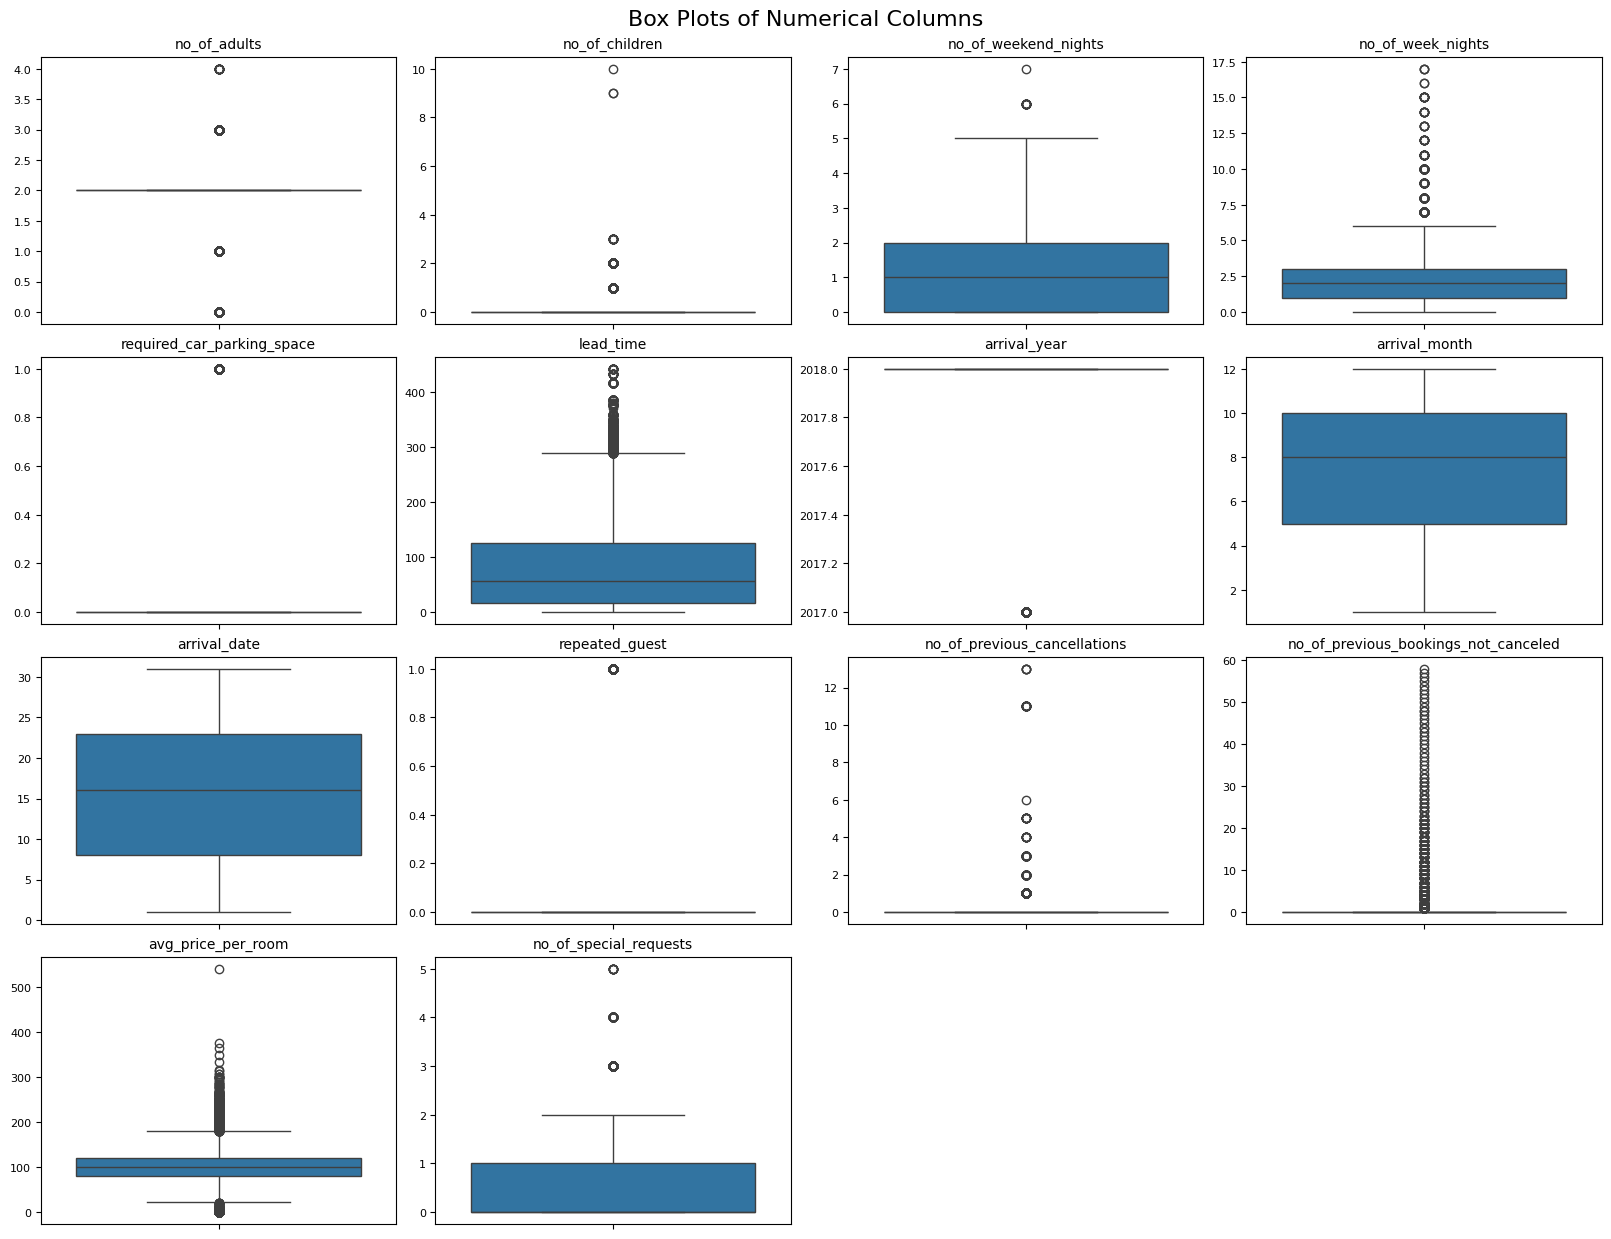

In [56]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude 'booking_status' if it's considered target and already handled
if 'booking_status' in numerical_cols:
    numerical_cols.remove('booking_status')

# Determine grid size for subplots
num_plots = len(numerical_cols)
num_cols = 4 # You can adjust this number for desired column layout
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], showfliers=True) # showfliers=True to see outliers
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('') # Remove y-label to avoid clutter
    axes[i].tick_params(axis='y', labelsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Box Plots of Numerical Columns', fontsize=16, y=1.02)
plt.show()

### No Outlier treatment as the values are legit and adding value to the Model

## Feature Engineering and Test Train Split

In [57]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [58]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [59]:
X = df.drop(["booking_status"], axis=1) # specifying the independent  and dependent variables
y = df["booking_status"]

In [60]:
X = sm.add_constant(X) # adding a constant to the independent variables

In [61]:
X = pd.get_dummies(X,columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True, dtype=int) # creating dummy variables and converting to int

In [62]:
X.head()

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,1.0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1.0,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,0,0,1,0,0,0,0,0,0,0,0,0,1
2,1.0,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1.0,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,1.0,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0,0,0,1,0,0,0,0,0,0,0,0,0,1


In [63]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   const                                 36275 non-null  float64
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   required_car_parking_space            36275 non-null  int64  
 6   lead_time                             36275 non-null  int64  
 7   arrival_year                          36275 non-null  int64  
 8   arrival_month                         36275 non-null  int64  
 9   arrival_date                          36275 non-null  int64  
 10  repeated_guest                        36275 non-null  int64  
 11  no_of_previous_

In [64]:
# splitting data in train(70%) and test(30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [65]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Number of rows in train data = 25392
Number of rows in test data = 10883
Percentage of classes in training set:
booking_status
0    0.670644
1    0.329356
Name: proportion, dtype: float64
Percentage of classes in test set:
booking_status
0    0.676376
1    0.323624
Name: proportion, dtype: float64


# Model Building

In [66]:
# fitting logistic regression model
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit(disp=False)

print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25364
Method:                           MLE   Df Model:                           27
Date:                Sun, 01 Feb 2026   Pseudo R-squ.:                  0.3293
Time:                        15:04:04   Log-Likelihood:                -10793.
converged:                      False   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -924.5923    120.817     -7.653      0.000   -1161.390    -687.795
no_of_adults                             0.1135      

## Summary of Logistic Regression Model Output

The output displays the results of a Logistic Regression model fitted using the Maximum Likelihood Estimation (MLE) method.

### General Model Information
- **Dependent Variable (Dep. Variable):** `booking_status`
- **Number of Observations (No. Observations):** 25,392 (This is the size of  training data `X_train`)
- **Model:** Logit (Logistic Regression)
- **Method:** MLE (Maximum Likelihood Estimation)

### Model Fit Statistics
- **Pseudo R-squ.:** 0.3293. This is a measure of how well the model fits the data, similar to R-squared in linear regression. A value of 0.3293 indicates that approximately 32.93% of the variance in the `booking_status` can be explained by the model's predictors.
- **Log-Likelihood:** -10793.0
- **LL-Null:** -16091. (Log-Likelihood of the null model with only an intercept)
- **LLR p-value:** 0.000. The Likelihood Ratio Test (LLR) p-value is extremely small, indicating that the model with predictors is significantly better than a null model without any predictors.
- **Converged:** **False**. This is a critical observation. It means the optimization algorithm did not reach a stable solution. This can happen for several reasons, including:
    - **Multicollinearity:** High correlation between predictor variables.
    - **Complete or Quasi-complete Separation:** When a predictor perfectly separates the classes of the dependent variable.
    - **Scale of variables:** Predictors with very different scales.
    - **Limited data:** Not enough observations for the complexity of the model.

**Implication of Non-Convergence:** When the model does not converge, the estimated coefficients and their standard errors may be unreliable. This means the interpretations of individual predictor effects should be treated with caution, and further steps might be needed to achieve convergence (e.g., check for multicollinearity, feature scaling, remove problematic variables, or increase data size if possible).

### Coefficients and Statistical Significance
Each row represents a predictor variable, showing its estimated coefficient, standard error, z-statistic, and p-value.

**Interpretation of Coefficients (assuming convergence was achieved and they are reliable):**
- A positive coefficient means that as the predictor variable increases, the log-odds of `booking_status` being 1 (Canceled) increase, making cancellation more likely.
- A negative coefficient means that as the predictor variable increases, the log-odds of `booking_status` being 1 (Canceled) decrease, making cancellation less likely.

**Highly Significant Predictors (P>|z| < 0.05):**
Many variables show very low p-values, suggesting they are statistically significant in predicting booking status. Some notable ones include:
- `const` (intercept)
- `no_of_adults`, `no_of_children`, `no_of_weekend_nights`, `no_of_week_nights`
- `required_car_parking_space` (negative coefficient, so having parking space decreases cancellation likelihood)
- `lead_time` (positive coefficient, longer lead time increases cancellation likelihood)
- `arrival_year` (positive, suggests bookings in later years are more prone to cancellation or that 2018 had higher cancellations)
- `arrival_month` (negative, suggesting certain months have lower cancellation rates)
- `repeated_guest` (strongly negative, repeated guests are much less likely to cancel, aligning with EDA findings)
- `no_of_previous_cancellations` (positive, having previous cancellations increases current cancellation likelihood)
- `avg_price_per_room` (positive, higher price increases cancellation likelihood)
- `no_of_special_requests` (strongly negative, more special requests decrease cancellation likelihood, aligning with EDA findings)
- Many of the dummy variables for `type_of_meal_plan`, `room_type_reserved`, and `market_segment_type` also show significance.

**Non-Significant Predictors (P>|z| >= 0.05):**
- `arrival_date` (p-value ~0.801) seems not to be a significant predictor.
- `no_of_previous_bookings_not_canceled` (p-value ~0.258) is not significant.
- `type_of_meal_plan_Meal Plan 3` (p-value ~0.997) has an extremely large coefficient and standard error, indicating instability, likely due to very few observations in this category.
- `room_type_reserved_Room_Type 3` (p-value ~0.999) also shows similar instability.
- `market_segment_type_Complementary` (p-value ~1.000) also shows extreme instability, with a very large negative coefficient and an enormous standard error. This is a strong indicator of a multicollinearity issue or complete separation.

### Summary of Key Issues
- **Non-Convergence:** The primary concern is that the model did not converge. This means the current coefficients are not reliable estimates of the true population parameters.
- **Possible Multicollinearity/Separation:** The extremely large standard errors and p-values close to 1 for `type_of_meal_plan_Meal Plan 3`, `room_type_reserved_Room_Type 3`, and `market_segment_type_Complementary` suggest either severe multicollinearity or complete/quasi-complete separation for these variables. This is common when dummy variables are created, especially if a category has very few observations or perfectly predicts the outcome.

### Next Steps
- **Address Non-Convergence:** It is crucial to address the non-convergence issue before interpreting the model. This might involve:
    - Checking for and removing highly correlated predictor variables (multicollinearity).
- **Refine Feature Set:** Based on the p-values and initial insights, consider removing non-significant predictors or combining less frequent categorical levels.

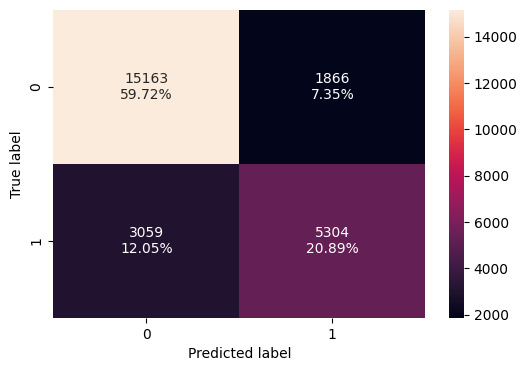

In [67]:
confusion_matrix_statsmodels(lg, X_train, y_train)

In [68]:
print("Training performance:")
model_performance_classification_statsmodels(lg, X_train, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.806041,0.634222,0.739749,0.682933


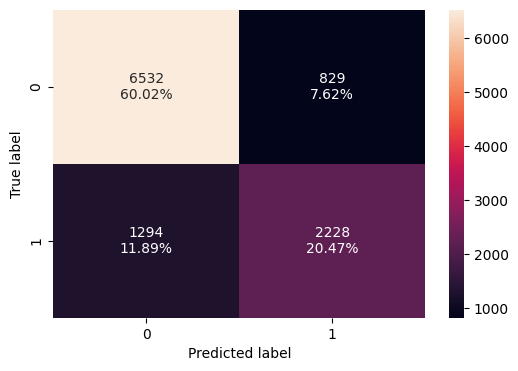

In [69]:
confusion_matrix_statsmodels(lg, X_test, y_test)

In [70]:
print("Testing performance:")
model_performance_classification_statsmodels(lg, X_test, y_test)

Testing performance:


,Accuracy,Recall,Precision,F1
0,0.804925,0.632595,0.728819,0.677307


### **Model Performance Summary**

### **Training Performance**
- **Accuracy:** 0.8060  
- **Recall:** 0.6342  
- **Precision:** 0.7397  
- **F1‑score:** 0.6829  

### **Test Performance**
- **Accuracy:** 0.8049  
- **Recall:** 0.6326  
- **Precision:** 0.7288  
- **F1‑score:** 0.6773  

### **Key Observation**
The model performs consistently across training and test sets, indicating no clear overfitting. However, since the model did not converge, these results should be interpreted cautiously. Addressing the convergence issue is necessary before relying on these metrics.


### Detecting and Dealing with Multicollinearity

In [71]:
#Checking for multicollinearity using VIF
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Features"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif
vif_before = calculate_vif(X_train)
print("VIF before removing variables:\n", vif_before)

VIF before removing variables:
                                 Features           VIF
0                                  const  3.946816e+07
1                           no_of_adults  1.348154e+00
2                         no_of_children  1.978229e+00
3                   no_of_weekend_nights  1.069475e+00
4                      no_of_week_nights  1.095667e+00
5             required_car_parking_space  1.039928e+00
6                              lead_time  1.394914e+00
7                           arrival_year  1.430830e+00
8                          arrival_month  1.275673e+00
9                           arrival_date  1.006738e+00
10                        repeated_guest  1.783516e+00
11          no_of_previous_cancellations  1.395689e+00
12  no_of_previous_bookings_not_canceled  1.651986e+00
13                    avg_price_per_room  2.050421e+00
14                no_of_special_requests  1.247278e+00
15         type_of_meal_plan_Meal Plan 2  1.271851e+00
16         type_of_meal_plan_Meal

In [72]:
vif_larger = calculate_vif(X_train)[calculate_vif(X_train)["VIF"] > 5]
vif_larger

,Features,VIF
0,const,3.946816e+07
25,market_segment_type_Corporate,1.692844e+01
26,market_segment_type_Offline,6.411392e+01
27,market_segment_type_Online,7.117643e+01


In [73]:
X_train1 = X_train.drop("market_segment_type_Online", axis=1)

vif_after = calculate_vif(X_train1)
print("VIF after dropping market_segment_type_Online ")
vif_after

VIF after dropping market_segment_type_Online 


,Features,VIF
0,const,3.939137e+07
1,no_of_adults,1.331784e+00
2,no_of_children,1.977350e+00
3,no_of_weekend_nights,1.069039e+00
4,no_of_week_nights,1.095118e+00
5,required_car_parking_space,1.039795e+00
6,lead_time,1.390637e+00
7,arrival_year,1.428376e+00
8,arrival_month,1.274625e+00
9,arrival_date,1.006721e+00


**No Multicollinearity after removing the columns `market_segment_type_Online`**

In [74]:
X_test1 = X_test.drop("market_segment_type_Online", axis=1)

### Removing High p-Value columns

In [75]:
# initial list of columns
cols = X_train1.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train1[cols]

    # fitting the model
    model = sm.Logit(y_train, X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'repeated_guest', 'no_of_previous_cancellations', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_segment_type_Corporate', 'market_segment_type_Offline']


In [76]:
X_train2 = X_train1[selected_features]

In [77]:
X_test2 = X_test1[selected_features]

In [78]:
logit1 = sm.Logit(y_train, X_train2.astype(float))
lg1 = logit1.fit()

print(lg1.summary())

Optimization terminated successfully.
         Current function value: 0.425677
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25370
Method:                           MLE   Df Model:                           21
Date:                Sun, 01 Feb 2026   Pseudo R-squ.:                  0.3283
Time:                        15:04:13   Log-Likelihood:                -10809.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -917.2860    120.456     -7.615    

**Now no categorical feature has p-value greater than 0.05, so we'll consider the features in X_train2 as the final ones and lg1 as final model.**

In [79]:
X_train_final = X_train2
X_test_final = X_test2

In [80]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25392 entries, 13662 to 33003
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   const                           25392 non-null  float64
 1   no_of_adults                    25392 non-null  int64  
 2   no_of_children                  25392 non-null  int64  
 3   no_of_weekend_nights            25392 non-null  int64  
 4   no_of_week_nights               25392 non-null  int64  
 5   required_car_parking_space      25392 non-null  int64  
 6   lead_time                       25392 non-null  int64  
 7   arrival_year                    25392 non-null  int64  
 8   arrival_month                   25392 non-null  int64  
 9   repeated_guest                  25392 non-null  int64  
 10  no_of_previous_cancellations    25392 non-null  int64  
 11  avg_price_per_room              25392 non-null  float64
 12  no_of_special_requests          2

### Model Performance across Different Metrics

**Our model can make wrong predictions as:**

1.  **False Negative (Type II Error):** Predicting a booking will **not be canceled** (actual booking_status = 0), but in reality, the booking **is canceled** (actual booking_status = 1).

2.  **False Positive (Type I Error):** Predicting a booking **will be canceled** (actual booking_status = 1), but in reality, the booking **is not canceled** (actual booking_status = 0).


**Which case is more important?**

*   Both cases are important for INN Hotels Group, but they have different impacts:

    *   **False Negative:** If we predict a booking will *not* be canceled, but it actually *is* canceled, the hotel might keep the room reserved, missing the opportunity to re-sell it. This leads to **direct revenue loss** and inefficient resource allocation (e.g., preparing a room that remains empty). This aligns with the problem statement's focus on revenue losses due to cancellations.

    *   **False Positive:** If we predict a booking *will* be canceled, but it actually *is not* canceled, the hotel might overbook the room or not have it ready for the guest. This can lead to **customer dissatisfaction, damage to the hotel's reputation**, and potential operational chaos. The guest might arrive to find no room, creating a very negative experience.

    Given the problem statement emphasizes **revenue loss**, minimizing False Negatives (identifying actual cancellations) is crucial. However, maintaining customer satisfaction means False Positives also need to be managed carefully.


**How to reduce this loss?**

*   We need to reduce both False Negatives and False Positives to optimize both revenue and customer experience.

*   To achieve this balance, the **`f1_score` should be maximized**. A higher F1-score indicates a better balance between precision (minimizing false positives) and recall (minimizing false negatives), thereby reducing both types of costly errors and correctly identifying both canceled and not-canceled bookings.

  * fi_score is computed as
  $$f1\_score = \frac{2 * Precision * Recall}{Precision + Recall}$$

In [81]:
print("Training performance model training:")
model_performance_classification_statsmodels(lg1, X_train_final, y_train)

Training performance model training:


,Accuracy,Recall,Precision,F1
0,0.805411,0.632548,0.739033,0.681657


In [82]:
print("Test performance model test:")
model_performance_classification_statsmodels(lg1, X_test_final, y_test)

Test performance model test:


,Accuracy,Recall,Precision,F1
0,0.804649,0.630892,0.729003,0.676408


**Converting coefficients to odds**

* The coefficients ($\beta$s) of the logistic regression model are in terms of $log(odds)$ and to find the odds, we have to take the exponential of the coefficients
* Therefore, **$odds =  exp(\beta)$**
* The percentage change in odds is given as $(exp(\beta) - 1) * 100$

In [83]:
# converting coefficients to odds
odds = np.exp(lg1.params)

# finding the percentage change
perc_change_odds = (np.exp(lg1.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train_final.columns).T

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Offline
Odds,0.0,1.114754,1.164360,1.114753,1.042636,0.203048,1.015835,1.573235,0.958528,0.064797,1.257157,1.019348,0.229941,1.179916,1.330892,0.700461,0.753830,0.479403,0.380991,0.239033,0.452584,0.167504
Change_odd%,-100.0,11.475363,16.436009,11.475256,4.263629,-79.695231,1.583521,57.323511,-4.147245,-93.520258,25.715665,1.934790,-77.005947,17.991562,33.089244,-29.953888,-24.617006,-52.059666,-61.900934,-76.096691,-54.741616,-83.249628


### **Coeffieicent Interpretations**

- **no_of_adults** — Odds: 1.1148 → **+11.48%** cancellation odds per additional adult.  
- **no_of_children** — Odds: 1.1644 → **+16.44%** per additional child.  
- **no_of_weekend_nights** — Odds: 1.1148 → **+11.48%** per extra weekend night.  
- **no_of_week_nights** — Odds: 1.0426 → **+4.26%** per extra weeknight.  
- **required_car_parking_space** — Odds: 0.2030 → **−79.70%**; guests needing parking are far less likely to cancel.  
- **lead_time** — Odds: 1.0158 → **+1.58%** per extra day; longer lead times increase cancellation likelihood.  
- **arrival_year** — Odds: 1.5732 → **+57.32%**; later years show higher cancellation rates.  
- **arrival_month** — Odds: 0.9585 → **−4.15%** per month; later months slightly reduce cancellations.  
- **repeated_guest** — Odds: 0.0648 → **−93.52%**; repeat guests rarely cancel.  
- **no_of_previous_cancellations** — Odds: 1.2572 → **+25.72%** per past cancellation.  
- **avg_price_per_room** — Odds: 1.0193 → **+1.93%** per price unit.  
- **no_of_special_requests** — Odds: 0.2299 → **−77.01%** per request; strong indicator of booking commitment.

---

## **Categorical Predictors**

- **type_of_meal_plan_Not Selected** — Odds: 1.3309 → **+33.09%** vs. Meal Plan 1.  
- **market_segment_type_Corporate** — Odds: 0.4526 → **−54.74%** vs. baseline.  
- **market_segment_type_Offline** — Odds: 0.1675 → **−83.25%** vs. baseline.

---

## **Overall Insight**
Strong commitment indicators: **parking requirement**, **repeat guest status**, and **special requests** (large reductions in cancellation odds).  
Strong risk indicators: **lead time**, **arrival year**, and **previous cancellations** (increase cancellation odds).



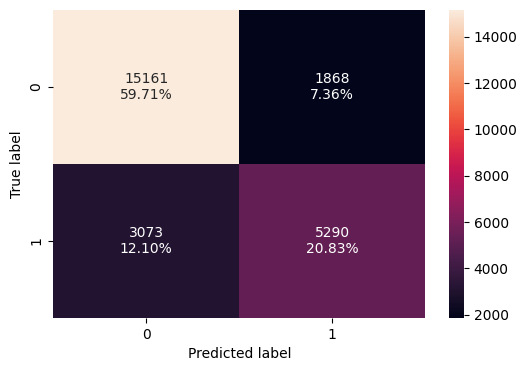

In [84]:
confusion_matrix_statsmodels(lg1, X_train_final, y_train)

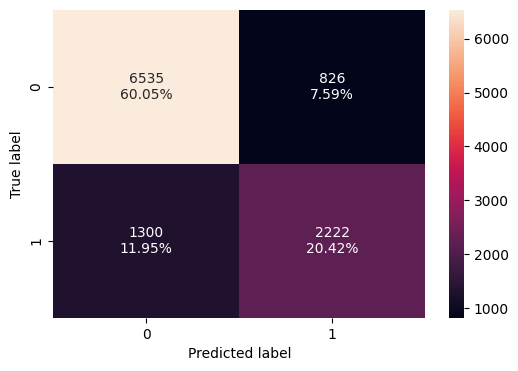

In [85]:
confusion_matrix_statsmodels(lg1, X_test_final, y_test)

# Model Performance Imporvement

* Let's see if the f1_score can be improved further by changing the model threshold
* First, we will check the ROC curve, compute the area under the ROC curve (ROC-AUC), and then use it to find the optimal threshold
* Next, we will check the Precision-Recall curve to find the right balance between precision and recall as our metric of choice is f1_score

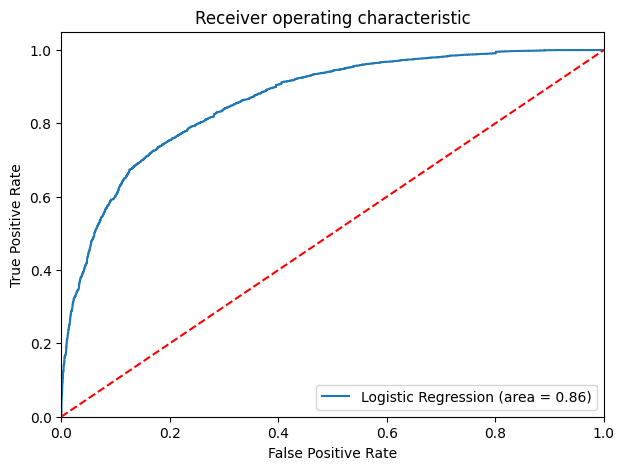

In [86]:
logit_roc_auc_train = roc_auc_score(y_train, lg1.predict(X_train_final))
fpr, tpr, thresholds = roc_curve(y_train, lg1.predict(X_train_final))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [87]:
# Optimal threshold as per ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, lg1.predict(X_train_final))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.3710466623488775


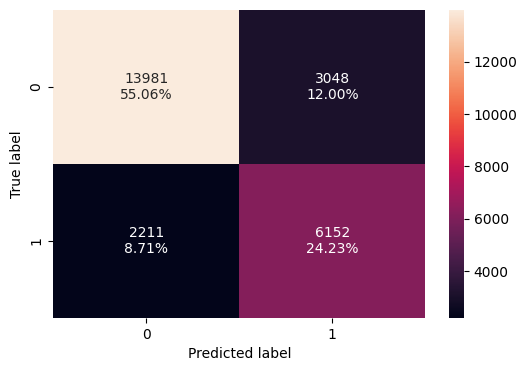

In [88]:
# creating confusion matrix
confusion_matrix_statsmodels(
    lg1, X_train_final, y_train, threshold=optimal_threshold_auc_roc
)

In [89]:
# checking model performance for this model
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg1, X_train_final, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.792888,0.735621,0.668696,0.700564


**`f1_score` of model has increased.**

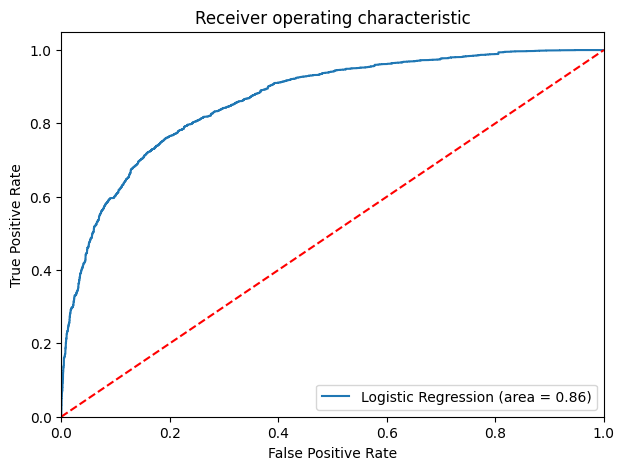

In [90]:
logit_roc_auc_test = roc_auc_score(y_test, lg1.predict(X_test_final))
fpr, tpr, thresholds = roc_curve(y_test, lg1.predict(X_test_final))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_test)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

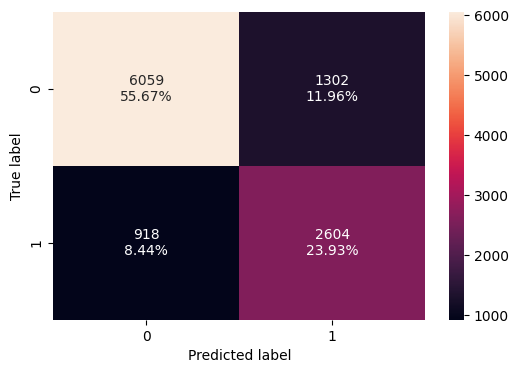

In [91]:
# creating confusion matrix
confusion_matrix_statsmodels(lg1, X_test_final, y_test, threshold=optimal_threshold_auc_roc)

In [92]:
# checking model performance for this model
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg1, X_test_final, y_test, threshold=optimal_threshold_auc_roc
)
print("Test performance:")
log_reg_model_test_perf_threshold_auc_roc

Test performance:


,Accuracy,Recall,Precision,F1
0,0.796012,0.739353,0.666667,0.701131


### Precision-Recall Curve

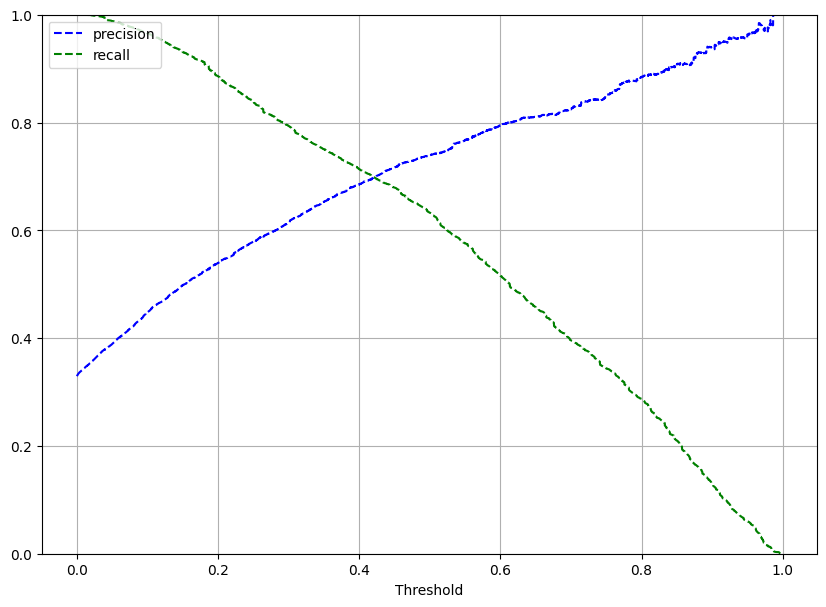

In [93]:
y_scores = lg1.predict(X_train_final)
prec, rec, tre = precision_recall_curve(y_train, y_scores,)

def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
    plt.grid(True) # Added grid here

plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)

plt.show()

In [94]:
# # Optimal threshold as per Precision-Recall curve
# The optimal cut off would be where we have a balance between precision and recall
precision, recall, thresholds = precision_recall_curve(y_train, lg1.predict(X_train_final))

optimal_idx = np.argmin(np.abs(precision - recall))
optimal_threshold_pr = thresholds[optimal_idx]
print(f'optimal_threshold_curve {optimal_threshold_pr}')

optimal_threshold_curve 0.420957461425391


# **Model Performance Comparison and Final Model Selection**

In [95]:
log_reg_model_train_perf = model_performance_classification_statsmodels(
    lg1, X_train_final, y_train)
log_reg_model_train_perf_auc_roc = model_performance_classification_statsmodels(
    lg1, X_train_final, y_train, threshold = 0.37 )
log_reg_model_train_perf_prec_recall = model_performance_classification_statsmodels(
    lg1, X_train_final, y_train, threshold=0.42 )

In [96]:

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_model_train_perf_auc_roc.T,
        log_reg_model_train_perf_prec_recall.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression-default Threshold",
    "Logistic Regression-0.37 Threshold",
    "Logistic Regression-0.42 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression-default Threshold,Logistic Regression-0.37 Threshold,Logistic Regression-0.42 Threshold
Accuracy,0.805411,0.792651,0.801276
Recall,0.632548,0.736219,0.699390
Precision,0.739033,0.668077,0.697888
F1,0.681657,0.700495,0.698638


In [97]:
log_reg_model_test_perf = model_performance_classification_statsmodels(
    lg1, X_test_final, y_test)
log_reg_model_test_perf_auc_roc = model_performance_classification_statsmodels(
    lg1, X_test_final, y_test, threshold = 0.37 )
log_reg_model_test_perf_prec_recall = model_performance_classification_statsmodels(
    lg1, X_test_final, y_test, threshold=0.42 )

In [98]:

models_test_comp_df = pd.concat(
    [
        log_reg_model_test_perf.T,
        log_reg_model_test_perf_auc_roc.T,
        log_reg_model_test_perf_prec_recall.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression-default Threshold",
    "Logistic Regression-0.37 Threshold",
    "Logistic Regression-0.42 Threshold",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Logistic Regression-default Threshold,Logistic Regression-0.37 Threshold,Logistic Regression-0.42 Threshold
Accuracy,0.804649,0.795553,0.803639
Recall,0.630892,0.739637,0.703861
Precision,0.729003,0.665730,0.693815
F1,0.676408,0.700740,0.698802


### **Model Selection Summary**

All three models perform well on both training and test sets, showing no signs of overfitting.

The **logistic regression model with a 0.37 threshold** delivers the strongest overall results across accuracy, recall, precision, and F1‑score, making it the preferred choice for predicting booking cancellations.

Using this threshold:
- **Predicted probability > 0.37** → classify as **canceled**  
- **Predicted probability ≤ 0.37** → classify as **not canceled**

This cutoff provides a balanced trade‑off between identifying true cancellations `(recall)` and reducing false alarms `(precision`).




## Building a Decision Tree Model

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   type_of_meal_plan                     36275 non-null  object 
 5   required_car_parking_space            36275 non-null  int64  
 6   room_type_reserved                    36275 non-null  object 
 7   lead_time                             36275 non-null  int64  
 8   arrival_year                          36275 non-null  int64  
 9   arrival_month                         36275 non-null  int64  
 10  arrival_date                          36275 non-null  int64  
 11  market_segment_

In [100]:
X = df.drop("booking_status", axis=1)
y = df["booking_status"]

In [101]:
X = pd.get_dummies(X, drop_first=True)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1)

In [103]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(25392, 27) (10883, 27) (25392,) (10883,)


In [104]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [105]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [106]:
##  Function to calculate recall score
def get_recall_score(model):
    '''
    model : classifier to predict values of X

    '''
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
    print("Recall on test set : ",metrics.recall_score(y_test,pred_test))

In [107]:
dTree = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dTree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

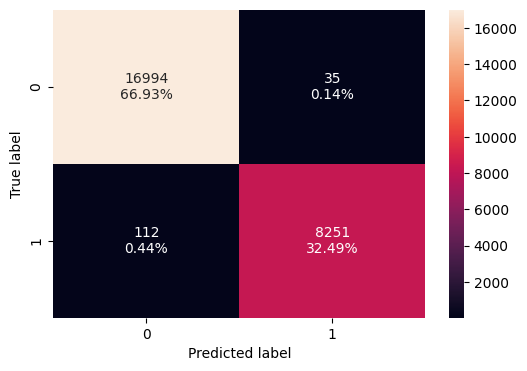

In [108]:
confusion_matrix_sklearn(dTree, X_train, y_train)

In [109]:
#performance measures in training data
decision_tree_perf_train = model_performance_classification_sklearn(dTree, X_train, y_train)
print("Training performance model0:")
decision_tree_perf_train

Training performance model0:


,Accuracy,Recall,Precision,F1
0,0.994211,0.986608,0.995776,0.991171


Test performance model0:


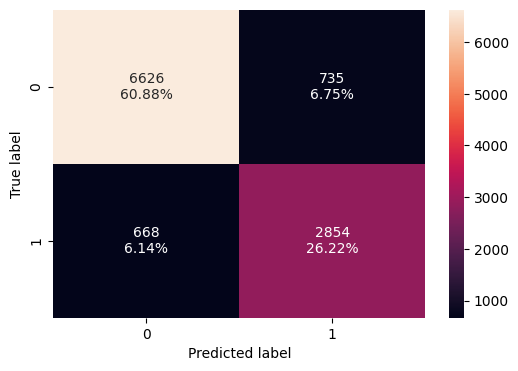

In [110]:
print("Test performance model0:")
confusion_matrix_sklearn(dTree, X_test, y_test) #performance measures in test data

In [111]:
decision_tree_perf_test = model_performance_classification_sklearn(dTree, X_test, y_test)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.871083,0.810335,0.795208,0.8027


In [112]:
feature_names = list(X.columns)
print(feature_names)

['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary', 'market_segment_type_Corporate', 'market_segment_type_Offline', 'market_segment_type_Online']


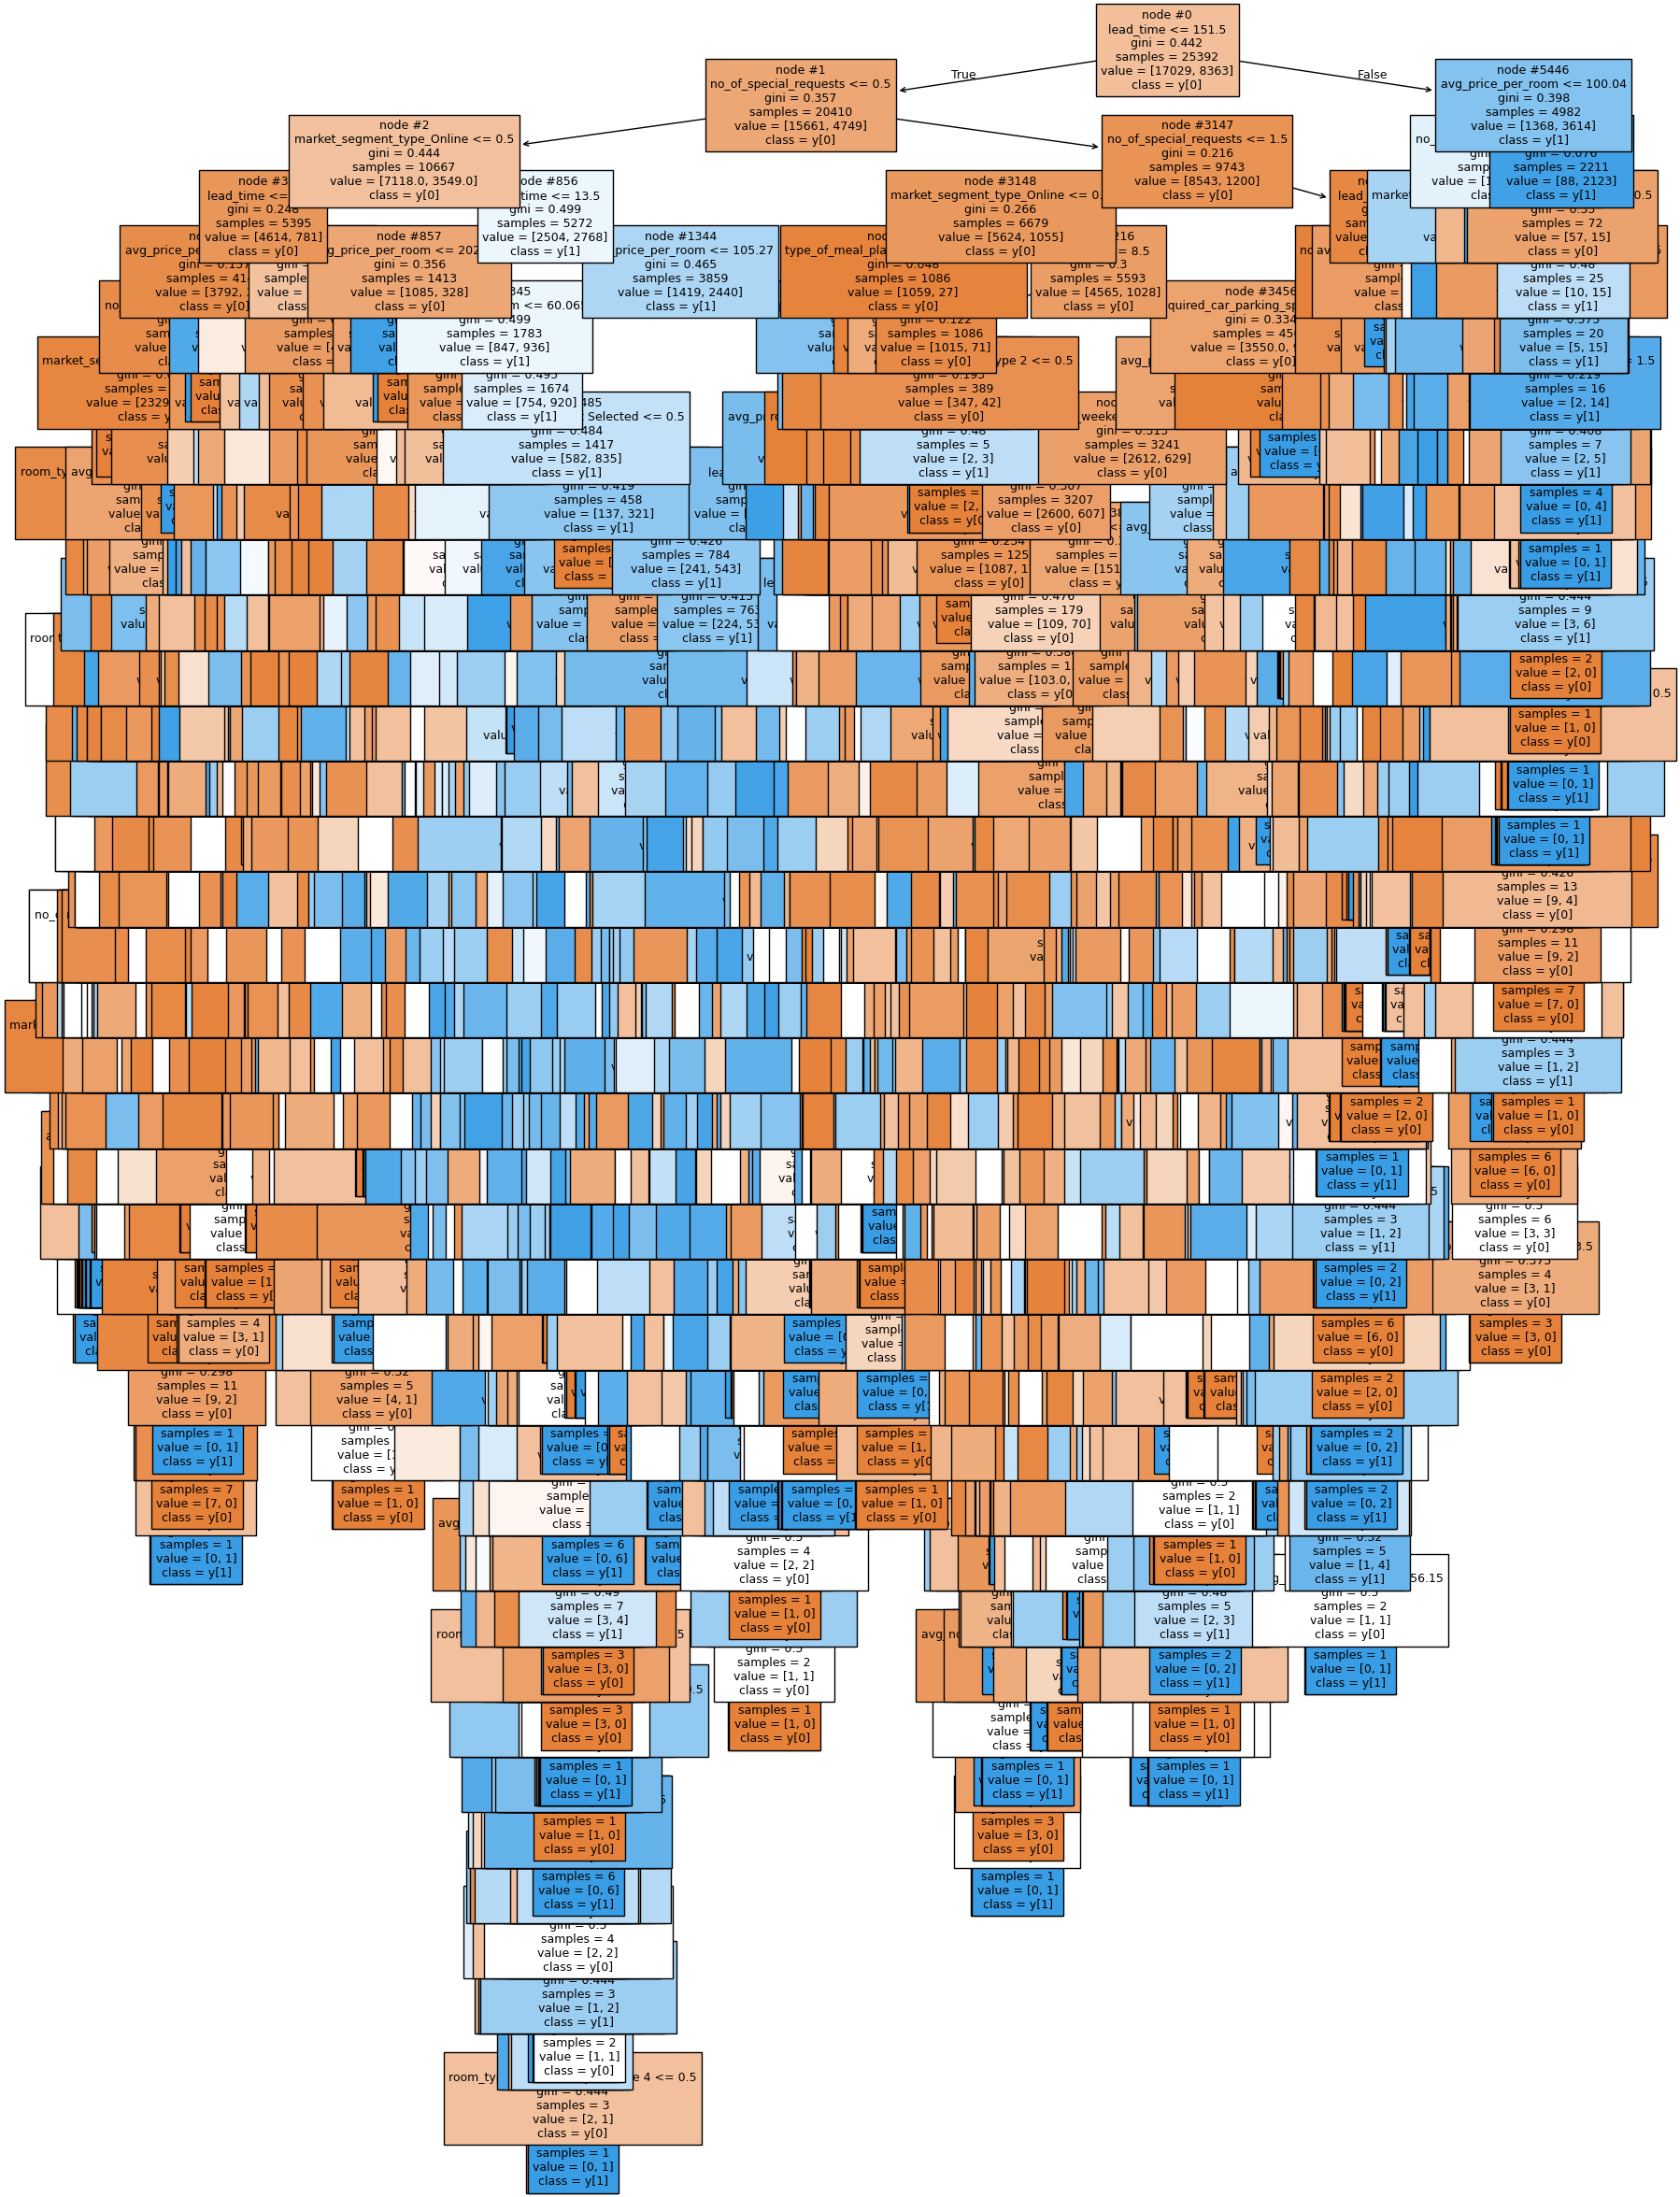

In [113]:
 plt.figure(figsize=(20,30))
tree.plot_tree(dTree,feature_names=feature_names,filled=True,fontsize=9,node_ids=True,class_names=True)
plt.show()

In [114]:
print(tree.export_text(dTree,feature_names=feature_names,show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- avg_price_per_room <= 201.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |--- lead_time <= 16.50
|   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 <= 0.50
|   |   |   |   |   |   |   |   |   |--- repeated_guest <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- lead_time <= 11.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 13
|   |   |   |   |   |   |   |   |   |   |--- lead_time >  11.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |--- repeated_guest >  0.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [147.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type

In [115]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(dTree.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                           Imp
lead_time                             0.350353
avg_price_per_room                    0.177265
market_segment_type_Online            0.092345
arrival_date                          0.085259
no_of_special_requests                0.067948
arrival_month                         0.064570
no_of_week_nights                     0.045395
no_of_weekend_nights                  0.038528
no_of_adults                          0.027482
arrival_year                          0.011793
type_of_meal_plan_Not Selected        0.008234
room_type_reserved_Room_Type 4        0.006904
required_car_parking_space            0.006878
market_segment_type_Offline           0.003927
type_of_meal_plan_Meal Plan 2         0.003704
no_of_children                        0.003672
room_type_reserved_Room_Type 5        0.001681
room_type_reserved_Room_Type 2        0.001486
market_segment_type_Corporate         0.000646
repeated_guest                        0.000601
room_type_res

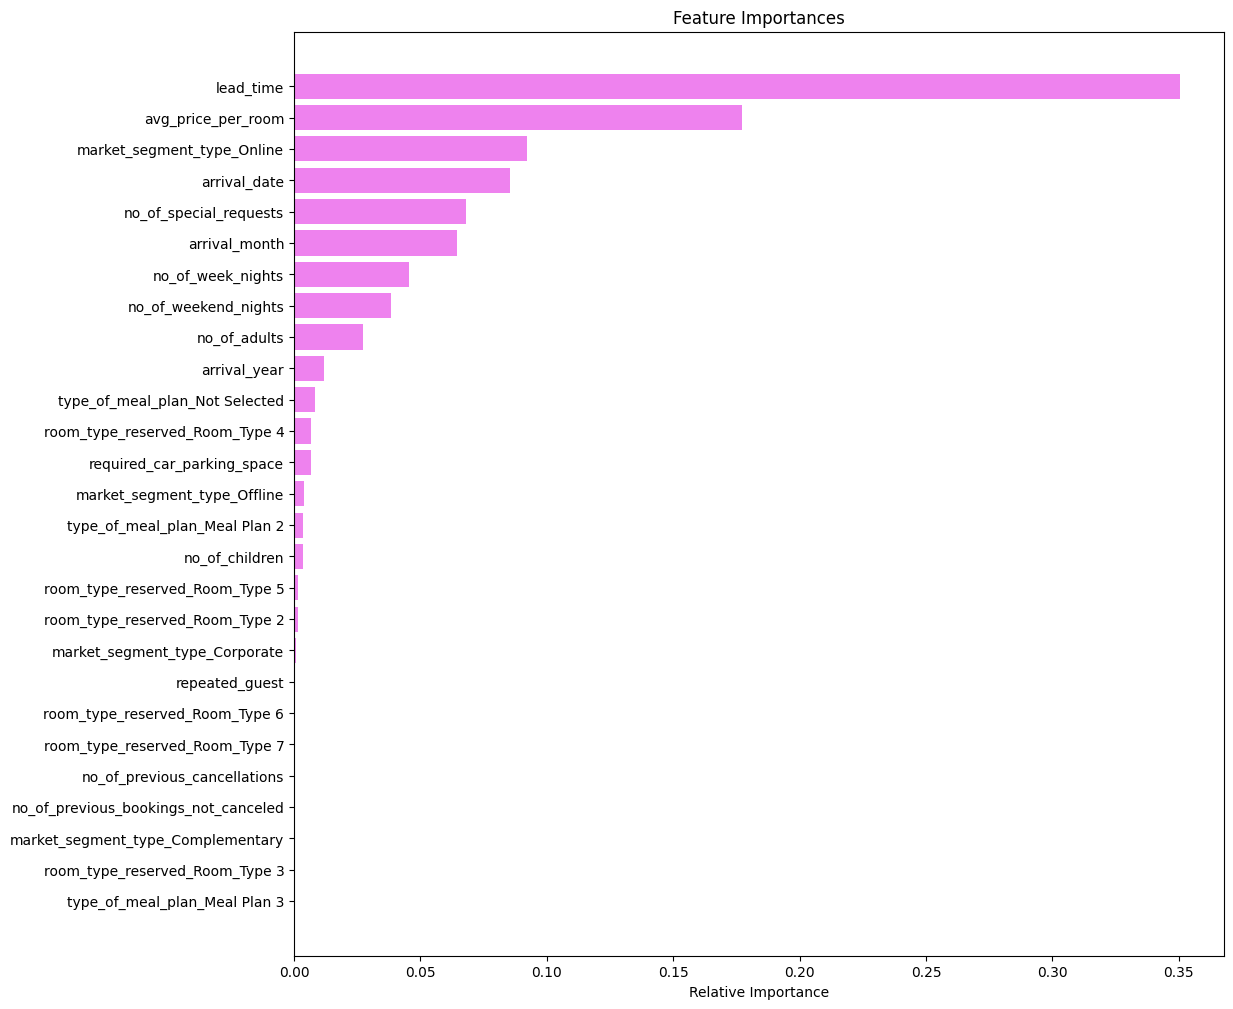

In [116]:
importances = dTree.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### **Top 3 Most Important Features**

The model identifies three predictors as having the strongest influence on booking cancellation outcomes. These features contribute the most to the model’s decision‑making process and therefore play a central role in understanding guest behavior.

### **1. lead_time**
This is the number of days between the booking date and the arrival date.  
A longer lead time often increases uncertainty, giving guests more opportunity to change plans. As a result, it becomes a powerful indicator of cancellation likelihood.

### **2. avg_price_per_room**
This represents the average daily room rate for the booking.  
Higher prices can make guests more cautious or more likely to cancel if they find better deals elsewhere. Its strong importance suggests that pricing dynamics significantly influence cancellation behavior.

### **3. market_segment_type_Online**
This feature captures whether the booking was made through an online channel.  
Online bookings tend to be more flexible and easier to cancel, which may explain why this segment shows a strong association with cancellation risk.

These three features collectively highlight how **timing**, **pricing**, and **booking channel** shape cancellation patterns.


## Prune tree

In [117]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1, class_weight="balanced")

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(2, 7, 2),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(6),
                       max_leaf_nodes=50, min_samples_split=10, random_state=1)

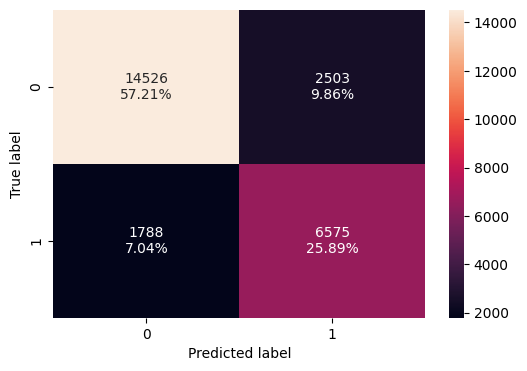

In [118]:
confusion_matrix_sklearn(estimator, X_train, y_train)

In [119]:

decision_tree_tune_perf_train = model_performance_classification_sklearn(estimator, X_train, y_train)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.83101,0.786201,0.724278,0.753971


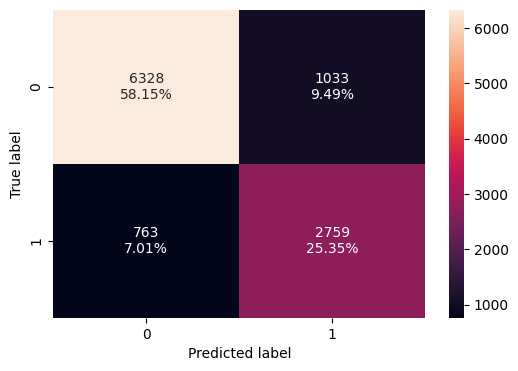

In [120]:
confusion_matrix_sklearn(estimator, X_test, y_test)

In [121]:

decision_tree_tune_perf_test = model_performance_classification_sklearn(estimator, X_test, y_test)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.834972,0.783362,0.727584,0.754444


**Visualizing Tree**

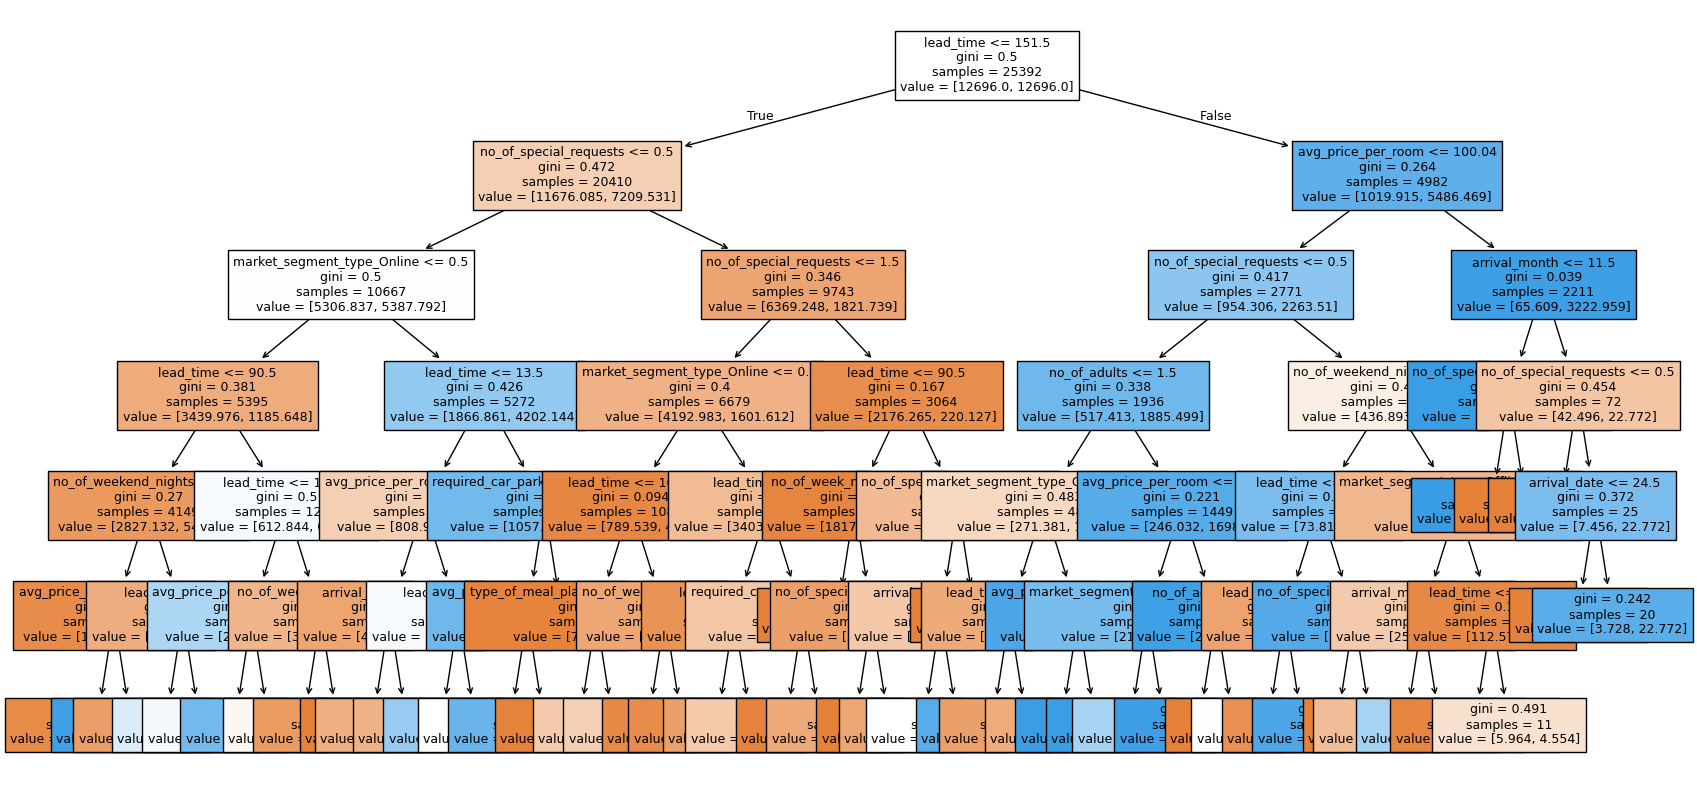

In [122]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [123]:
# Text report showing the rules of a decision tree -
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |--- avg_price_per_room <= 196.50
|   |   |   |   |   |   |--- weights: [1736.39, 132.08] class: 0
|   |   |   |   |   |--- avg_price_per_room >  196.50
|   |   |   |   |   |   |--- weights: [0.75, 25.81] class: 1
|   |   |   |   |--- no_of_weekend_nights >  0.50
|   |   |   |   |   |--- lead_time <= 68.50
|   |   |   |   |   |   |--- weights: [960.27, 223.16] class: 0
|   |   |   |   |   |--- lead_time >  68.50
|   |   |   |   |   |   |--- weights: [129.73, 160.92] class: 1
|   |   |   |--- lead_time >  90.50
|   |   |   |   |--- lead_time <= 117.50
|   |   |   |   |   |--- avg_price_per_room <= 93.58
|   |   |   |   |   |   |--- weights: [214.72, 227.72] class: 1
|   |   |   |   |   |--- avg_price_per_room >  93.58
|   |   |   |   |   |   |--- weights: [82.76, 285.41] 

### **Decision Tree Interpretation**

- The decision tree spans several levels, showing that it evaluates multiple conditions before reaching a final prediction.  
- The first split is based on **lead_time**. If the lead time is **≤ 151.50 days**, the tree then examines the **number of special requests**.  
- When a booking has **no special requests**, the model continues branching using features such as **market segment type**, **lead_time**, **average price per room**, and **number of weekend nights** to determine the outcome.



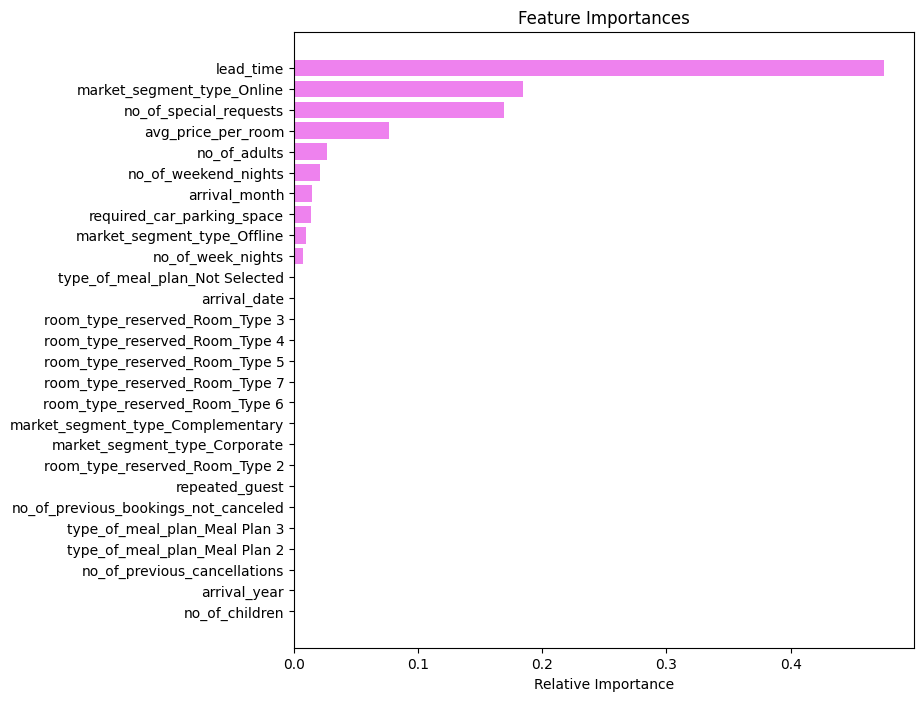

In [124]:
# importance of features in the tree building

importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### Post Pruning

In [125]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [126]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,0.008376
1,-2.710505e-20,0.008376
2,2.933821e-20,0.008376
3,2.933821e-20,0.008376
4,2.933821e-20,0.008376
...,...,...
1837,8.901596e-03,0.328058
1838,9.802243e-03,0.337860
1839,1.271875e-02,0.350579
1840,3.412090e-02,0.418821


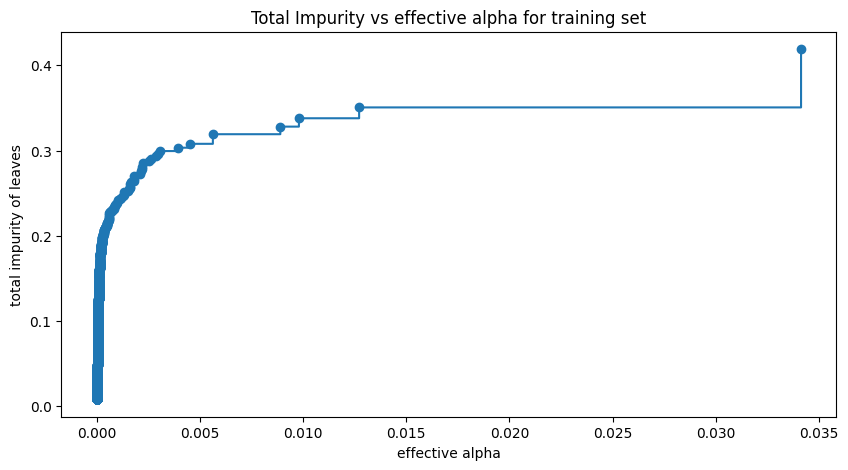

In [127]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

### Training the Pruned Decision Tree

Next, a decision tree is trained using the sequence of effective `ccp_alphas`.  
The final value in `ccp_alphas` represents the pruning level that collapses the entire tree, resulting in a model (`clfs[-1]`) with only a single node.


In [128]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08117914389136943


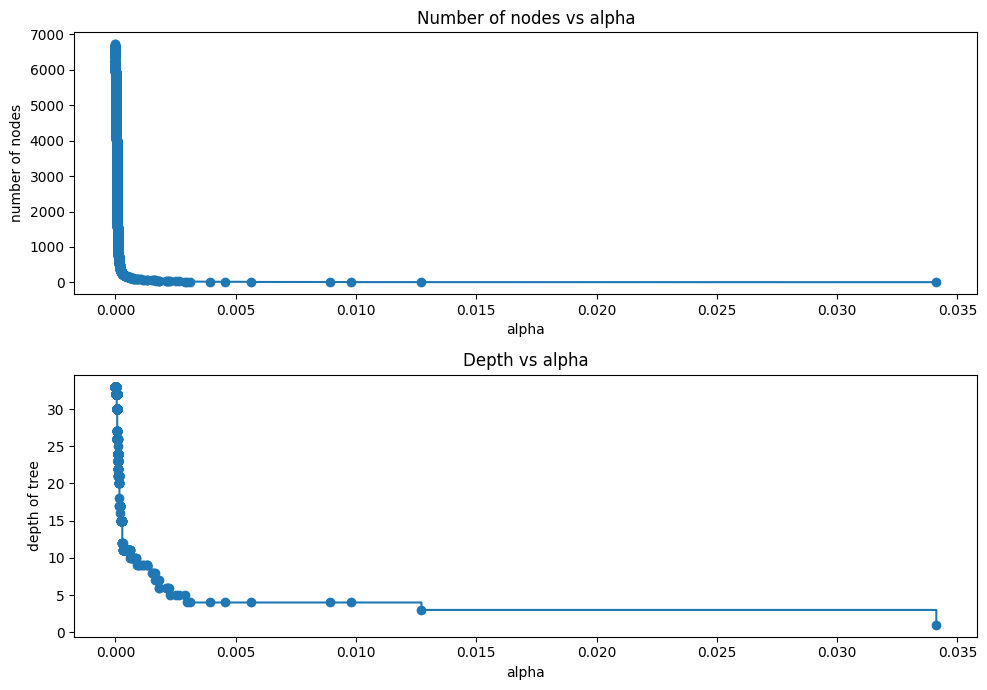

In [129]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

**F1 Score vs alpha for training and testing sets**

In [130]:
f1_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = f1_score(y_train, pred_train)
    f1_train.append(values_train)

f1_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = f1_score(y_test, pred_test)
    f1_test.append(values_test)

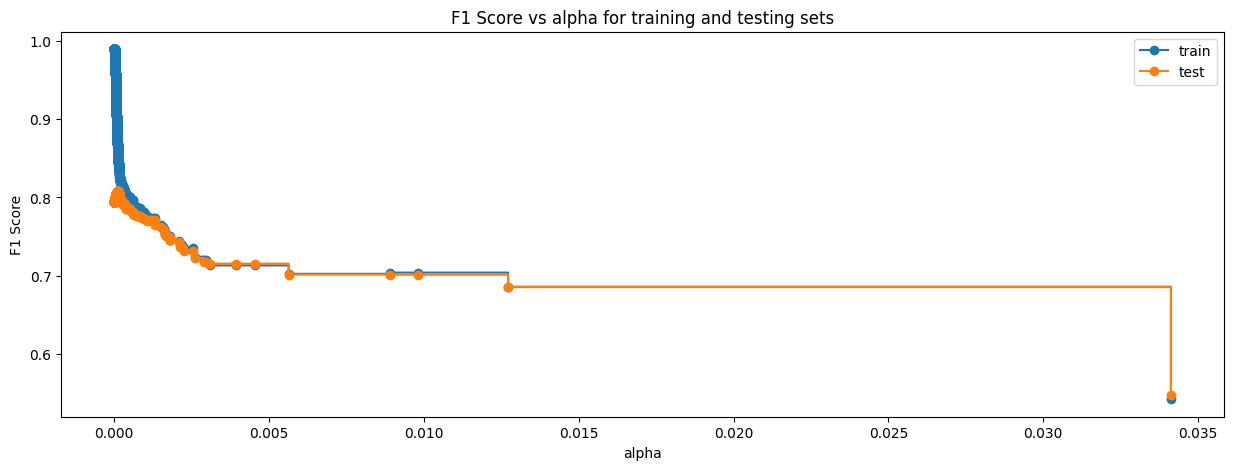

In [131]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs alpha for training and testing sets")
ax.plot(ccp_alphas, f1_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, f1_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [132]:
index_best_model = np.argmax(f1_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0001226763315516701),
                       class_weight='balanced', random_state=1)


**Checking performance on training set**

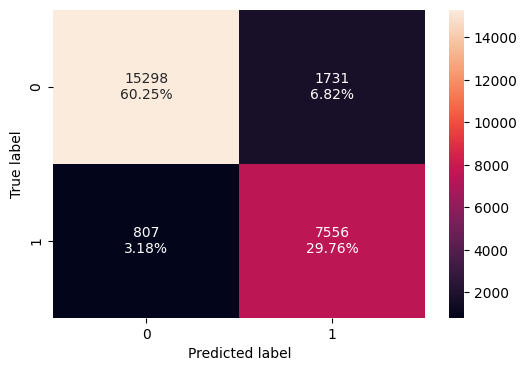

In [133]:
confusion_matrix_sklearn(best_model, X_train, y_train)

In [134]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.900047,0.903504,0.81361,0.856204


Checking performance on Test set

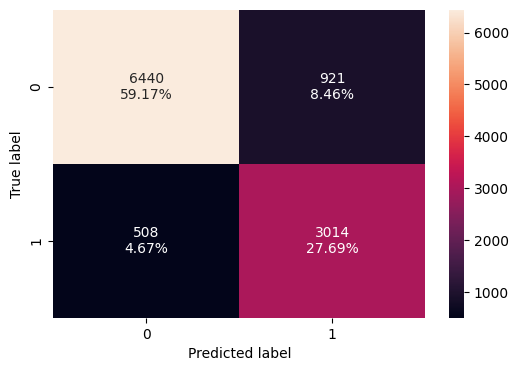

In [135]:
confusion_matrix_sklearn(best_model, X_test, y_test)

In [136]:
decision_tree_post_test = model_performance_classification_sklearn(
    best_model, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.868694,0.855764,0.765947,0.808368


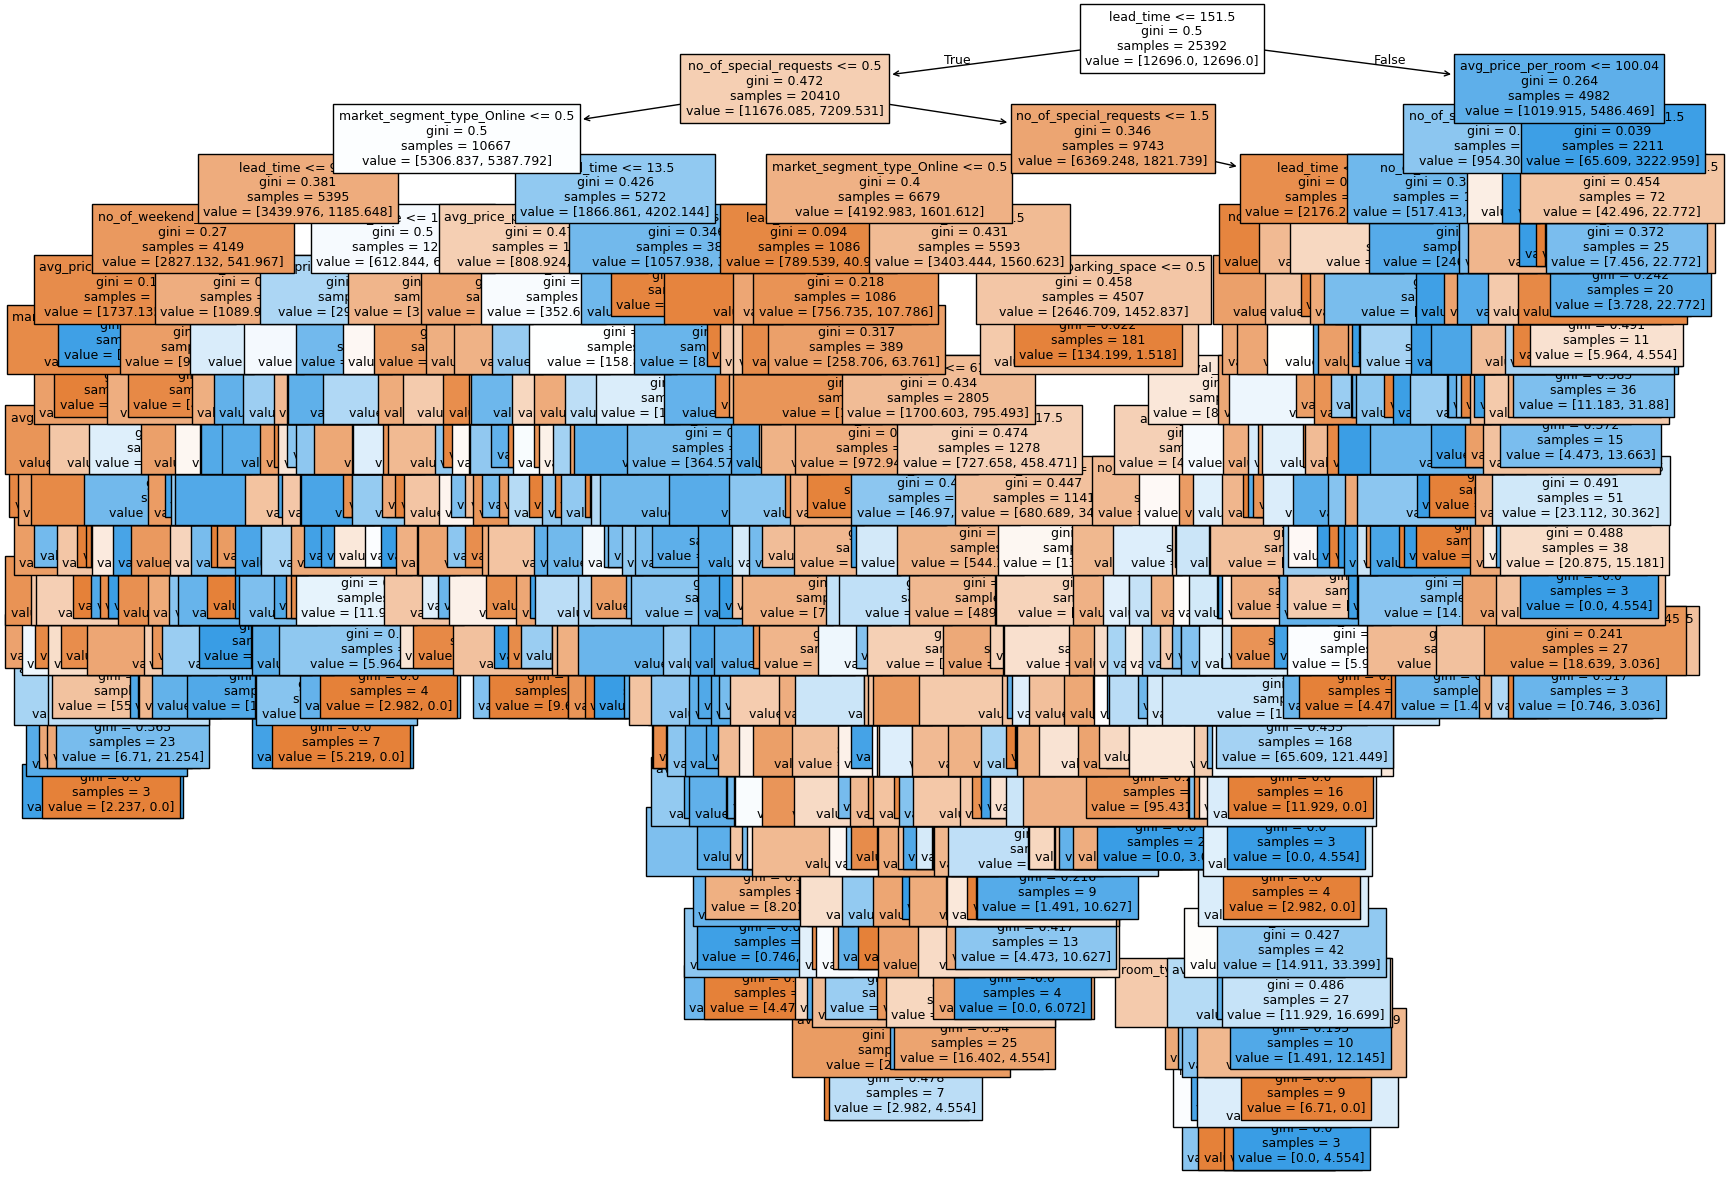

In [137]:
plt.figure(figsize=(20, 15)) #show the decision tree

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [138]:

# Text report showing the rules of a decision tree -

print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |--- avg_price_per_room <= 196.50
|   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |--- lead_time <= 16.50
|   |   |   |   |   |   |   |   |--- avg_price_per_room <= 68.50
|   |   |   |   |   |   |   |   |   |--- weights: [207.26, 10.63] class: 0
|   |   |   |   |   |   |   |   |--- avg_price_per_room >  68.50
|   |   |   |   |   |   |   |   |   |--- arrival_date <= 29.50
|   |   |   |   |   |   |   |   |   |   |--- no_of_adults <= 1.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- no_of_adults >  1.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |--- arrival_date >  29.50
|   |   |   |

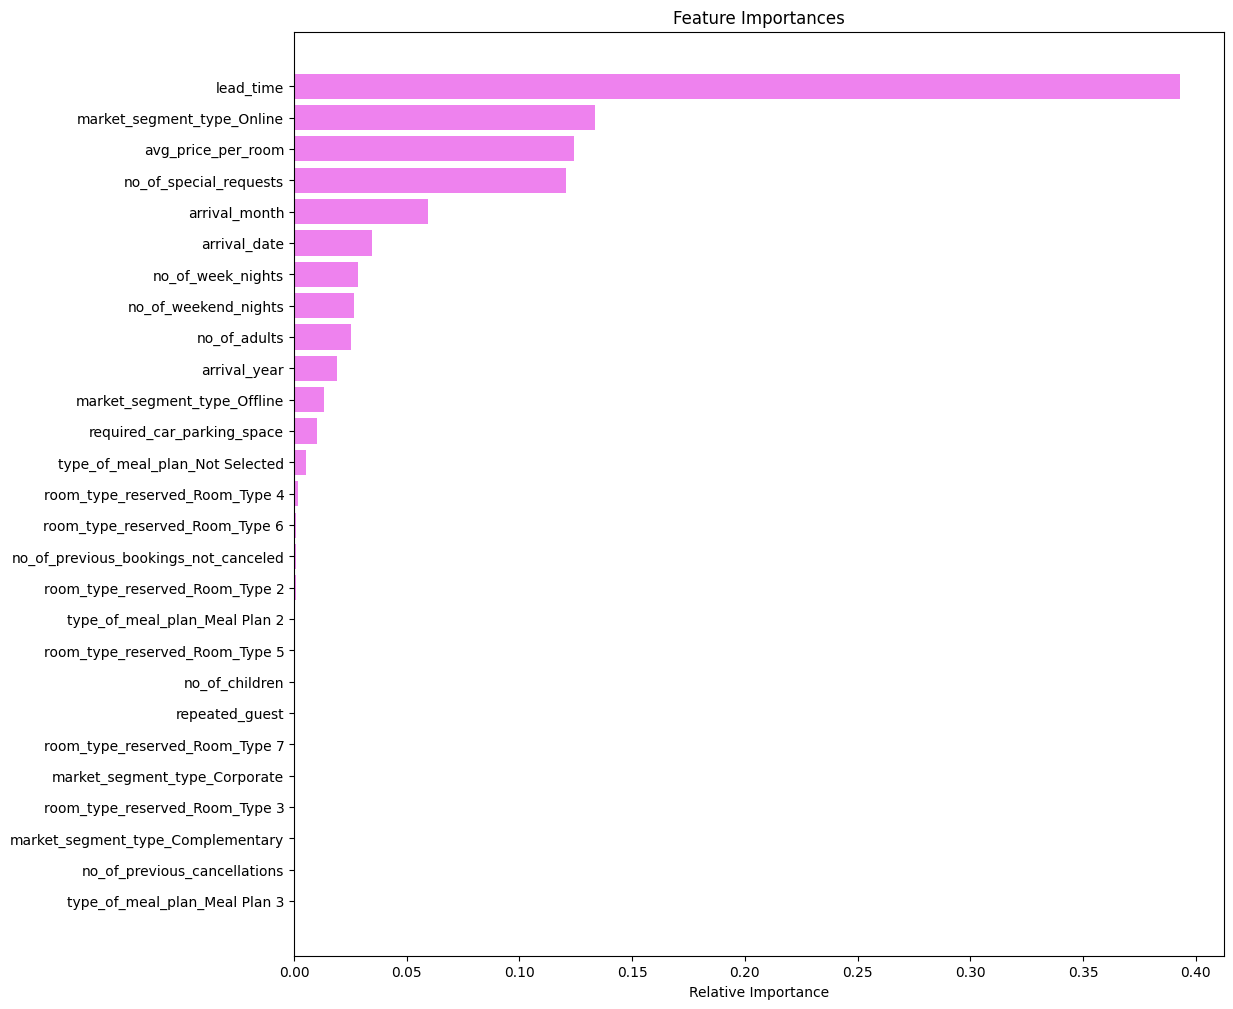

In [139]:
importances = best_model.feature_importances_ #displaying feature importance graph
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [140]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree sklearn",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree sklearn,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.994211,0.831010,0.900047
Recall,0.986608,0.786201,0.903504
Precision,0.995776,0.724278,0.813610
F1,0.991171,0.753971,0.856204


In [141]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
       decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.871083,0.834972,0.868694
Recall,0.810335,0.783362,0.855764
Precision,0.795208,0.727584,0.765947
F1,0.802700,0.754444,0.808368


## **Model Insights and Strategic Recommendations**

### **Performance of the Post‑Pruned Decision Tree**
- The **post‑pruned decision tree** achieves the **highest recall** on the test set, making it the strongest model for identifying true cancellations.  
- Its structure remains **simple and interpretable**, allowing clear visibility into how decisions are made.

### **Key Decision Rules Identified**
- **Lead Time:** Bookings with a lead time **greater than 151.50 days** show a higher likelihood of cancellation.  
- **Average Price per Room:** When the average room price exceeds **€196.50**, the probability of cancellation increases.



---

## **Recommended Predictive Model**
The **logistic regression model with a 0.37 threshold** delivers the best overall performance across accuracy, precision, recall, and F1‑score.  
- **Predicted probability > 0.37 → Canceled**  
- **Predicted probability ≤ 0.37 → Not canceled**  

This threshold provides a balanced approach, improving both cancellation detection and precision.

For maximizing recall specifically, the **post‑pruned decision tree** remains the top choice.

---



## **Profitable Cancellation & Refund Policies**

### **1. Tiered Refund Structure**
Introduce a refund policy where the refundable amount **decreases as the check‑in date approaches**.  
- Encourages early cancellations  
- Increases the chance of reselling rooms  

### **2. Flexible Modification Options**
Allow guests to **modify their booking** up to a certain number of days before arrival.  
- Reduces unnecessary cancellations  
- Improves customer satisfaction  

---

## **Additional Recommendations for INN Hotels**

### **1. Focus on High‑Impact Predictors**
Based on the decision tree, the hotel should closely monitor:
- **Lead time**  
- **Online market segment**  
- **Average price per room**

These variables strongly influence cancellation behavior.

### **2. Optimize Pricing for Online Channels**
Online bookings (64% of total) often come with higher prices due to platform dynamics like convenience and comparison tools.  
- Tailored promotions or dynamic pricing can help attract and retain online customers.

### **3. Leverage Seasonal Booking Trends**
Booking volume:
- **Rises from August**,  
- **Peaks in October (5317 bookings)**,  
- Declines sharply in **December–February**, with **January lowest (1014 bookings)**.

**Recommendation:**  
Launch targeted **winter‑season campaigns**—discounts, bundled offers, or themed promotions—to boost occupancy during low‑demand months.

### **4. Align Operations With Demand**
- **High‑demand periods:** Increase staffing to maintain service quality.  
- **Low‑demand periods:** Adjust staffing and optimize operations to control costs.

### **5. Strengthen Loyalty Programs**
Repeat guests show a **much lower cancellation rate**.  
- Implement or enhance loyalty rewards to encourage repeat stays and reduce cancellations.

### **6. Continue Data Collection & Analysis**
Ongoing monitoring of:
- Cancellation reasons  
- Guest behavior  
- Market trends  

  will help refine predictive models and improve policy decisions over time.

---
